<a href="https://colab.research.google.com/github/raghav-upadhyay2002/RUL-prediction-using-LSTM-for-Aircraft-Engine/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# CELL 1: SETUP, DATA UPLOAD & LOADING
# NASA C-MAPSS Turbofan Engine Degradation Simulation Dataset
# 4 sub-datasets: FD001-FD004 | 21 sensors | Multiple operating conditions
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os, zipfile, io
warnings.filterwarnings('ignore')

# ── Upload & extract dataset (skip if already extracted) ─────────────────────
# Auto-detect where data files live
def find_data_dir():
    candidates = ['/content', '/content/CMAPSSData', '/content/CMAPSSData (2)']
    for d in candidates:
        if os.path.exists(os.path.join(d, 'train_FD001.txt')):
            return d
    return None

DATA_DIR = find_data_dir()

if DATA_DIR is None:
    from google.colab import files
    print("Please upload CMAPSSData.zip ...")
    uploaded = files.upload()
    for fname in uploaded.keys():
        with zipfile.ZipFile(io.BytesIO(uploaded[fname]), 'r') as z:
            z.extractall("/content/")
        print(f"Extracted: {fname}")
    DATA_DIR = find_data_dir()

print(f"Data directory: {DATA_DIR}")

# ── Column names for C-MAPSS ──────────────────────────────────────────────────
col_names = ['unit_id', 'cycle', 'op_1', 'op_2', 'op_3'] + [f's{i}' for i in range(1, 22)]

# ── Load all 4 sub-datasets ───────────────────────────────────────────────────
train_dfs, test_dfs, rul_dfs = {}, {}, {}
for i in range(1, 5):
    fd = f'FD00{i}'
    train_dfs[fd] = pd.read_csv(f'{DATA_DIR}/train_{fd}.txt', sep=r'\s+', header=None, names=col_names)
    test_dfs[fd]  = pd.read_csv(f'{DATA_DIR}/test_{fd}.txt',  sep=r'\s+', header=None, names=col_names)
    rul_dfs[fd]   = pd.read_csv(f'{DATA_DIR}/RUL_{fd}.txt',   sep=r'\s+', header=None, names=['RUL'])

print("\n=== Dataset Summary ===")
print(f"{'Dataset':<10} {'Train rows':<14} {'Test rows':<12} {'Engines (train)'}")
for fd in ['FD001','FD002','FD003','FD004']:
    n_eng = train_dfs[fd]['unit_id'].nunique()
    print(f"{fd:<10} {train_dfs[fd].shape[0]:<14} {test_dfs[fd].shape[0]:<12} {n_eng}")

print("\nDataset descriptions:")
print("  FD001 - 1 fault mode, 1 op condition (sea level)")
print("  FD002 - 1 fault mode, 6 op conditions")
print("  FD003 - 2 fault modes, 1 op condition")
print("  FD004 - 2 fault modes, 6 op conditions")
print("\nSample rows (FD001):")
train_dfs['FD001'].head(3)

Data directory: /content

=== Dataset Summary ===
Dataset    Train rows     Test rows    Engines (train)
FD001      20631          13096        100
FD002      53759          33991        260
FD003      24720          16596        100
FD004      61249          41214        249

Dataset descriptions:
  FD001 - 1 fault mode, 1 op condition (sea level)
  FD002 - 1 fault mode, 6 op conditions
  FD003 - 2 fault modes, 1 op condition
  FD004 - 2 fault modes, 6 op conditions

Sample rows (FD001):


,unit_id,cycle,op_1,op_2,op_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


DATASET OVERVIEW — NASA C-MAPSS Turbofan Engine Dataset

Domain    : Aerospace / Predictive Maintenance (Rolls-Royce scenario)
Task      : Predict Remaining Useful Life (RUL) of turbofan engines
Dataset   : CMAPSS (Commercial Modular Aero-Propulsion System Simulation)
Source    : NASA Ames Prognostics Data Repository
Sensors   : 21 sensors (temperatures, pressures, speeds, fuel flow)
Op Settings: 3 operational settings (altitude, Mach, throttle)
Sub-datasets: 4 (varying fault modes and operating conditions)

Sub-dataset characteristics:
  Dataset  Train rows   Test engines   Train engines   Fault modes  Op conditions
  FD001    20631        100            100             1            1
  FD002    53759        259            260             1            6
  FD003    24720        100            100             2            1
  FD004    61249        248            249             2            6

--- Data Quality Check (FD001) ---
  Missing values: 0 (dataset is complete)
  Data types: {dt

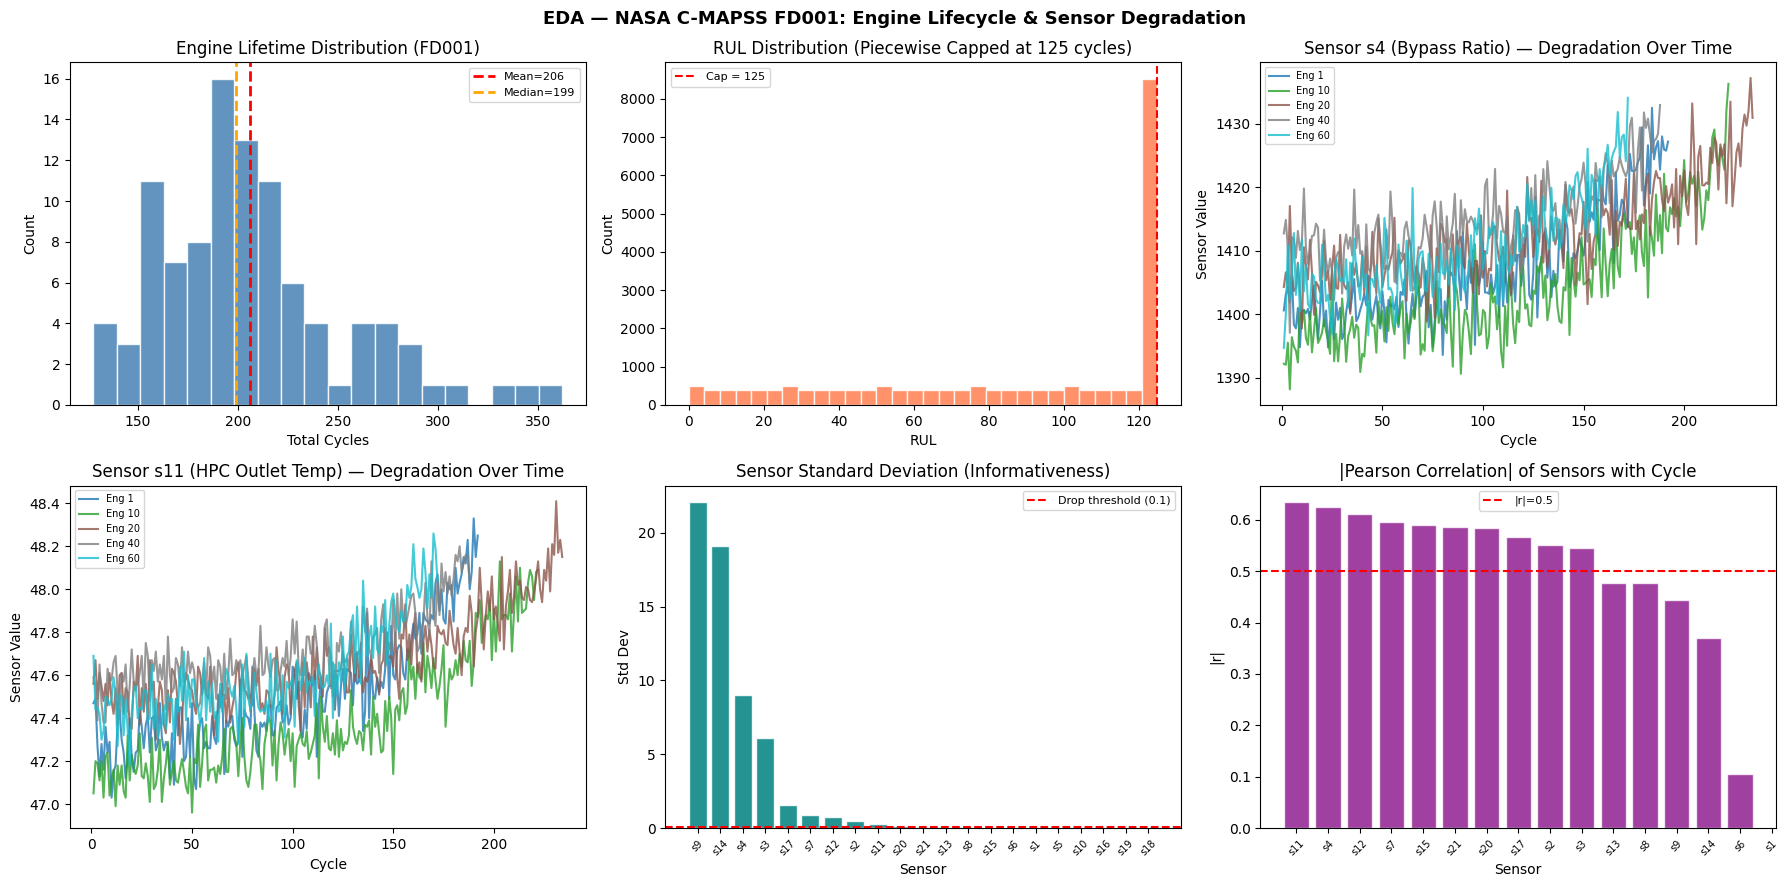


=== KEY EDA INSIGHTS ===
  1. Engine lifetimes: mean=206 cycles, range=[128, 362] cycles
  2. RUL distribution is right-skewed; piecewise linear cap at 125 normalises it
  3. Sensors s1,s5,s6,s10,s16,s18,s19 have near-zero variance → dropped
  4. Sensors s4,s11,s12,s14 show strongest correlation with degradation (|r|>0.5)
  5. FD002/FD004 have 6 op-conditions → require condition-aware normalization
  6. No missing values in dataset — clean but simulated data
  7. Multi-sensor temporal patterns justify RNN/LSTM sequence models


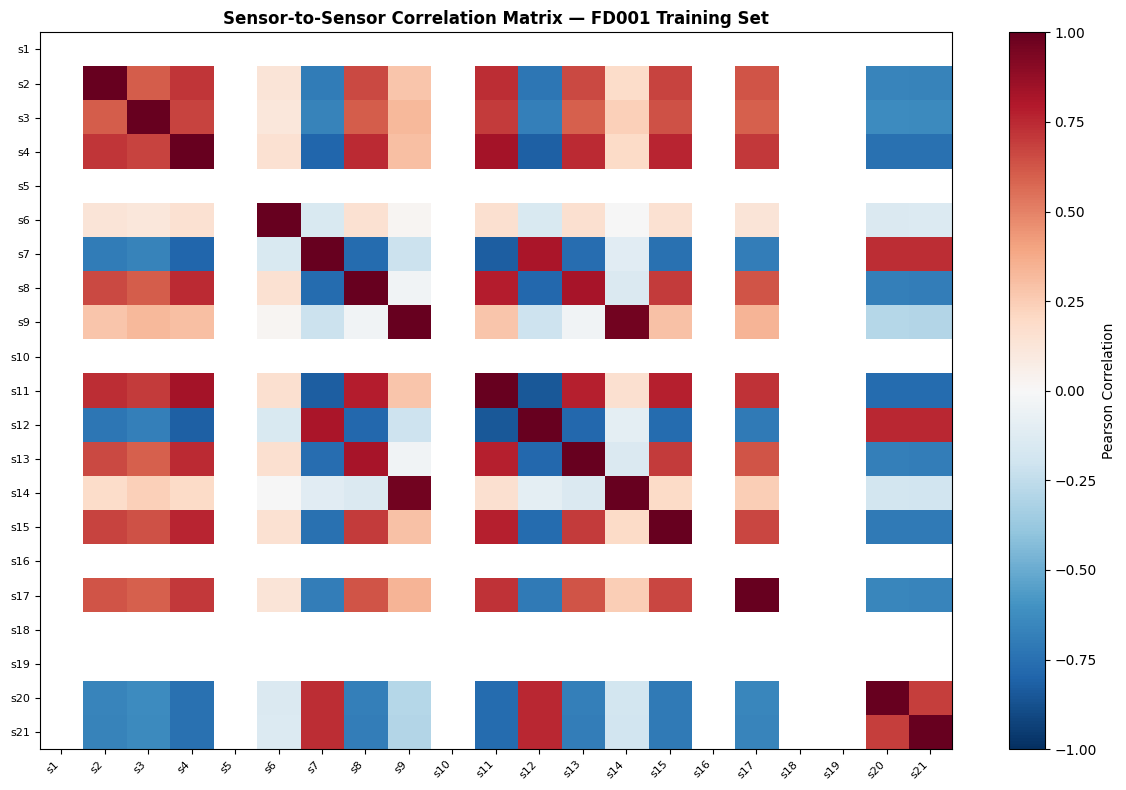


✓ EDA complete!


In [ ]:
# =============================================================================
# CELL 2: EXPLORATORY DATA ANALYSIS (EDA)
# Domain understanding, sensor analysis, degradation patterns, insights
# =============================================================================

# ── 2.1 Dataset Overview & Statistical Summary ────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW — NASA C-MAPSS Turbofan Engine Dataset")
print("=" * 60)
print("""
Domain    : Aerospace / Predictive Maintenance (Rolls-Royce scenario)
Task      : Predict Remaining Useful Life (RUL) of turbofan engines
Dataset   : CMAPSS (Commercial Modular Aero-Propulsion System Simulation)
Source    : NASA Ames Prognostics Data Repository
Sensors   : 21 sensors (temperatures, pressures, speeds, fuel flow)
Op Settings: 3 operational settings (altitude, Mach, throttle)
Sub-datasets: 4 (varying fault modes and operating conditions)
""")

print("Sub-dataset characteristics:")
print(f"  {'Dataset':<8} {'Train rows':<12} {'Test engines':<14} {'Train engines':<15} {'Fault modes':<12} {'Op conditions'}")
info = {'FD001':(1,1),'FD002':(1,6),'FD003':(2,1),'FD004':(2,6)}
for fd,(fm,oc) in info.items():
    n_tr = train_dfs[fd]['unit_id'].nunique()
    n_te = test_dfs[fd]['unit_id'].nunique()
    print(f"  {fd:<8} {train_dfs[fd].shape[0]:<12} {n_te:<14} {n_tr:<15} {fm:<12} {oc}")

# ── 2.2 Missing Values & Data Quality Check ──────────────────────────────────
print("\n--- Data Quality Check (FD001) ---")
missing = train_dfs['FD001'].isnull().sum().sum()
print(f"  Missing values: {missing} (dataset is complete)")
print(f"  Data types: {train_dfs['FD001'].dtypes.value_counts().to_dict()}")
print(f"  Shape: {train_dfs['FD001'].shape} (rows x columns)")

# ── 2.3 Statistical Summary ───────────────────────────────────────────────────
print("\n--- Sensor Statistical Summary (FD001 Training Set) ---")
sensor_cols = [f's{i}' for i in range(1, 22)]
print(train_dfs['FD001'][sensor_cols[:10]].describe().round(3).to_string())

# ── 2.4 Engine Lifecycle & Degradation Visualization ─────────────────────────
fd   = 'FD001'
df   = train_dfs[fd].copy()
max_cycles = df.groupby('unit_id')['cycle'].max()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('EDA — NASA C-MAPSS FD001: Engine Lifecycle & Sensor Degradation', fontsize=13, fontweight='bold')

# Plot 1: Engine lifetime histogram
axes[0,0].hist(max_cycles, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(max_cycles.mean(), color='red', ls='--', lw=2, label=f'Mean={max_cycles.mean():.0f}')
axes[0,0].axvline(max_cycles.median(), color='orange', ls='--', lw=2, label=f'Median={max_cycles.median():.0f}')
axes[0,0].set_title('Engine Lifetime Distribution (FD001)'); axes[0,0].set_xlabel('Total Cycles'); axes[0,0].set_ylabel('Count')
axes[0,0].legend(fontsize=8)

# Plot 2: RUL distribution in training data (after piecewise capping at 125)
max_c = df.groupby('unit_id')['cycle'].max().rename('max_c')
df_rul = df.join(max_c, on='unit_id')
df_rul['RUL_raw'] = df_rul['max_c'] - df_rul['cycle']
df_rul['RUL_capped'] = df_rul['RUL_raw'].clip(upper=125)
axes[0,1].hist(df_rul['RUL_capped'], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_title('RUL Distribution (Piecewise Capped at 125 cycles)'); axes[0,1].set_xlabel('RUL'); axes[0,1].set_ylabel('Count')
axes[0,1].axvline(125, color='red', ls='--', lw=1.5, label='Cap = 125')
axes[0,1].legend(fontsize=8)

# Plot 3: Sensor s4 degradation trend for 5 engines
sample_units = [1, 10, 20, 40, 60]
colors_eng = plt.cm.tab10(np.linspace(0, 1, len(sample_units)))
for k, uid in enumerate(sample_units):
    eng = df[df['unit_id'] == uid]
    axes[0,2].plot(eng['cycle'], eng['s4'], alpha=0.8, color=colors_eng[k], lw=1.5, label=f'Eng {uid}')
axes[0,2].set_title('Sensor s4 (Bypass Ratio) — Degradation Over Time')
axes[0,2].set_xlabel('Cycle'); axes[0,2].set_ylabel('Sensor Value'); axes[0,2].legend(fontsize=7)

# Plot 4: Sensor s11 trend
for k, uid in enumerate(sample_units):
    eng = df[df['unit_id'] == uid]
    axes[1,0].plot(eng['cycle'], eng['s11'], alpha=0.8, color=colors_eng[k], lw=1.5, label=f'Eng {uid}')
axes[1,0].set_title('Sensor s11 (HPC Outlet Temp) — Degradation Over Time')
axes[1,0].set_xlabel('Cycle'); axes[1,0].set_ylabel('Sensor Value'); axes[1,0].legend(fontsize=7)

# Plot 5: Sensor variance bar chart (informativeness)
sensor_std = df[sensor_cols].std().sort_values(ascending=False)
axes[1,1].bar(sensor_std.index, sensor_std.values, color='teal', edgecolor='white', alpha=0.85)
axes[1,1].axhline(0.1, color='red', ls='--', lw=1.5, label='Drop threshold (0.1)')
axes[1,1].set_title('Sensor Standard Deviation (Informativeness)'); axes[1,1].set_xlabel('Sensor'); axes[1,1].set_ylabel('Std Dev')
axes[1,1].tick_params(axis='x', rotation=45, labelsize=7); axes[1,1].legend(fontsize=8)

# Plot 6: Correlation with cycle (degradation proxy)
corr = df[sensor_cols + ['cycle']].corr()['cycle'].drop('cycle').abs().sort_values(ascending=False)
axes[1,2].bar(corr.index, corr.values, color='purple', edgecolor='white', alpha=0.75)
axes[1,2].set_title('|Pearson Correlation| of Sensors with Cycle'); axes[1,2].set_xlabel('Sensor'); axes[1,2].set_ylabel('|r|')
axes[1,2].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,2].axhline(0.5, color='red', ls='--', lw=1.5, label='|r|=0.5')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=120, bbox_inches='tight'); plt.show()

# ── 2.5 Key EDA Insights ─────────────────────────────────────────────────────
print("\n=== KEY EDA INSIGHTS ===")
print(f"  1. Engine lifetimes: mean={max_cycles.mean():.0f} cycles, range=[{max_cycles.min()}, {max_cycles.max()}] cycles")
print(f"  2. RUL distribution is right-skewed; piecewise linear cap at 125 normalises it")
print(f"  3. Sensors s1,s5,s6,s10,s16,s18,s19 have near-zero variance → dropped")
print(f"  4. Sensors s4,s11,s12,s14 show strongest correlation with degradation (|r|>0.5)")
print(f"  5. FD002/FD004 have 6 op-conditions → require condition-aware normalization")
print(f"  6. No missing values in dataset — clean but simulated data")
print(f"  7. Multi-sensor temporal patterns justify RNN/LSTM sequence models")

# ── 2.6 Sensor correlation heatmap (FD001) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df[sensor_cols].corr()
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(sensor_cols))); ax.set_yticks(range(len(sensor_cols)))
ax.set_xticklabels(sensor_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(sensor_cols, fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Sensor-to-Sensor Correlation Matrix — FD001 Training Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_sensors.png', dpi=120, bbox_inches='tight'); plt.show()
print("\n✓ EDA complete!")

In [ ]:
# =============================================================================
# CELL 3: DATA PREPROCESSING & FEATURE ENGINEERING
# RUL labeling, sensor selection, normalization, sliding-window sequences
# =============================================================================
from sklearn.preprocessing import StandardScaler

# ── 3.1 Configuration ─────────────────────────────────────────────────────────
RUL_CAP    = 125          # Piecewise-linear RUL cap (early cycles capped)
WINDOW     = 30           # Sliding window size (timesteps per sample)

# Sensors with near-zero variance across ALL datasets -> drop
DROP = ['s1','s5','s6','s10','s16','s18','s19']
OP_COLS  = ['op_1','op_2','op_3']
ALL_SENS = [f's{i}' for i in range(1,22)]
FEAT_COLS = OP_COLS + [s for s in ALL_SENS if s not in DROP]
print(f"Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}")
print(f"Dropped sensors: {DROP}")

# ── 3.2 RUL labeling helper ───────────────────────────────────────────────────
def compute_train_rul(df, cap=RUL_CAP):
    """Piecewise-linear capped RUL: flat at cap, then decreasing."""
    max_c = df.groupby('unit_id')['cycle'].max().rename('max_c')
    df = df.join(max_c, on='unit_id')
    df['RUL'] = (df['max_c'] - df['cycle']).clip(upper=cap)
    return df.drop(columns='max_c')

def compute_test_rul(test_df, rul_df, cap=RUL_CAP):
    """Assign RUL to test data using ground-truth last-cycle RUL."""
    last_c = test_df.groupby('unit_id')['cycle'].max()
    gt     = dict(zip(last_c.index, rul_df['RUL'].values))
    lc     = last_c.to_dict()
    test_df = test_df.copy()
    test_df['RUL'] = test_df.apply(
        lambda r: gt[r['unit_id']] + (lc[r['unit_id']] - r['cycle']), axis=1)
    return test_df.assign(RUL=test_df['RUL'].clip(upper=cap))

# ── 3.3 Z-score normalization (fit on train, transform test) ──────────────────
def normalize(tr, te, feats):
    sc = StandardScaler()
    tr, te = tr.copy(), te.copy()
    tr[feats] = sc.fit_transform(tr[feats])
    te[feats] = sc.transform(te[feats])
    return tr, te, sc

# ── 3.4 Process all 4 sub-datasets ───────────────────────────────────────────
proc_train, proc_test, scalers = {}, {}, {}
for fd in ['FD001','FD002','FD003','FD004']:
    tr = train_dfs[fd].drop(columns=DROP)
    te = test_dfs[fd].drop(columns=DROP)
    tr = compute_train_rul(tr)
    te = compute_test_rul(te, rul_dfs[fd])
    tr, te, sc = normalize(tr, te, FEAT_COLS)
    proc_train[fd], proc_test[fd], scalers[fd] = tr, te, sc
    print(f"[{fd}] Train: {tr.shape} | Test: {te.shape} | "
          f"RUL range train: [{tr['RUL'].min():.0f}, {tr['RUL'].max():.0f}]")

# ── 3.5 Sliding-window sequence builder ──────────────────────────────────────
def make_sequences(df, feats=FEAT_COLS, w=WINDOW):
    """Sliding window over each engine. Returns X:(N,w,F), y:(N,)."""
    X_list, y_list = [], []
    for _, grp in df.groupby('unit_id', sort=True):
        grp = grp.sort_values('cycle')
        data, labels = grp[feats].values, grp['RUL'].values
        T = len(grp)
        if T < w:                           # pad short engines
            pad = np.tile(data[0], (w-T,1))
            data = np.vstack([pad, data])
            labels = np.concatenate([np.full(w-T, labels[0]), labels])
            T = w
        for s in range(T - w + 1):
            X_list.append(data[s:s+w]); y_list.append(labels[s+w-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def make_test_sequences(df, feats=FEAT_COLS, w=WINDOW):
    """One window per engine (last w cycles)."""
    X_list, y_list = [], []
    for _, grp in df.groupby('unit_id', sort=True):
        grp = grp.sort_values('cycle')
        data = grp[feats].values; T = len(grp)
        seq = data[-w:] if T >= w else np.vstack([np.tile(data[0],(w-T,1)), data])
        X_list.append(seq); y_list.append(grp['RUL'].iloc[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# ── 3.6 Generate sequences ───────────────────────────────────────────────────
seq_X_tr, seq_y_tr = {}, {}
seq_X_te, seq_y_te = {}, {}
for fd in ['FD001','FD002','FD003','FD004']:
    seq_X_tr[fd], seq_y_tr[fd] = make_sequences(proc_train[fd])
    seq_X_te[fd], seq_y_te[fd] = make_test_sequences(proc_test[fd])
    print(f"[{fd}] Train X:{seq_X_tr[fd].shape}  Test X:{seq_X_te[fd].shape}")

N_FEAT = seq_X_tr['FD001'].shape[2]
INPUT  = (WINDOW, N_FEAT)
print(f"\nInput shape per sample: {INPUT}  (window={WINDOW} x features={N_FEAT})")
print("\n✓ Preprocessing & feature engineering complete!")

Feature columns (17): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Dropped sensors: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
[FD001] Train: (20631, 20) | Test: (13096, 20) | RUL range train: [0, 125]
[FD002] Train: (53759, 20) | Test: (33991, 20) | RUL range train: [0, 125]
[FD003] Train: (24720, 20) | Test: (16596, 20) | RUL range train: [0, 125]
[FD004] Train: (61249, 20) | Test: (41214, 20) | RUL range train: [0, 125]
[FD001] Train X:(17731, 30, 17)  Test X:(100, 30, 17)
[FD002] Train X:(46219, 30, 17)  Test X:(259, 30, 17)
[FD003] Train X:(21820, 30, 17)  Test X:(100, 30, 17)
[FD004] Train X:(54028, 30, 17)  Test X:(248, 30, 17)

Input shape per sample: (30, 17)  (window=30 x features=17)

✓ Preprocessing & feature engineering complete!


In [ ]:
# =============================================================================
# CELL 4: MODEL DESIGN & JUSTIFICATION
# Four LSTM-based architectures for RUL prediction
# =============================================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (Input, LSTM, Bidirectional, Dense,
    Dropout, BatchNormalization, Conv1D, MaxPooling1D, Layer)
tf.random.set_seed(42)

DROPOUT = 0.3

# ── Custom Temporal Attention Layer ──────────────────────────────────────────
# Justification: attention learns to focus on most degradation-critical
# timesteps, improving interpretability and accuracy.
class TemporalAttention(Layer):
    """Bahdanau-style additive attention over the time axis."""
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
    def call(self, x):
        score = tf.squeeze(tf.matmul(x, self.W), axis=-1)   # (B, T)
        alpha = tf.nn.softmax(score, axis=1)                 # (B, T)
        return tf.reduce_sum(x * tf.expand_dims(alpha, -1), axis=1), alpha  # (B, U), (B, T)

# ── Model 1: Vanilla Stacked LSTM ────────────────────────────────────────────
# Justification: baseline sequence model for temporal degradation patterns.
def build_vanilla_lstm(input_shape=INPUT):
    inp = Input(shape=input_shape, name='input')
    x = LSTM(128, return_sequences=True)(inp)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = LSTM(64)(x)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='linear', name='RUL')(x)
    m = Model(inp, out, name='VanillaLSTM')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

# ── Model 2: Bidirectional LSTM ──────────────────────────────────────────────
# Justification: BiLSTM captures both forward (early degradation) and
# backward (end-of-life) temporal patterns for richer feature extraction.
def build_bilstm(input_shape=INPUT):
    inp = Input(shape=input_shape)
    x = Bidirectional(LSTM(128, return_sequences=True))(inp)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = Bidirectional(LSTM(64))(x)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='linear', name='RUL')(x)
    m = Model(inp, out, name='StackedBiLSTM')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

# ── Model 3: LSTM + Temporal Attention ───────────────────────────────────────
# Justification: attention mechanism highlights which time-steps contribute
# most to RUL prediction – key for interpretability and degradation analysis.
def build_lstm_attention(input_shape=INPUT):
    inp = Input(shape=input_shape)
    x = LSTM(128, return_sequences=True)(inp)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    ctx, alpha = TemporalAttention()(x)           # context + attention weights
    x = Dropout(DROPOUT)(ctx)
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='linear', name='RUL')(x)
    m = Model(inp, out, name='LSTM_Attention')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

# ── Model 4: CNN + LSTM Hybrid ───────────────────────────────────────────────
# Justification: CNN extracts local degradation patterns (short-term trends),
# LSTM models long-range temporal dependencies. Hybrid leverages both.
def build_cnn_lstm(input_shape=INPUT):
    inp = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu', padding='same')(inp)
    x = Conv1D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x); x = Dropout(DROPOUT)(x)
    x = LSTM(128, return_sequences=False)(x)
    x = BatchNormalization()(x); x = Dropout(DROPOUT)(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(1, activation='linear', name='RUL')(x)
    m = Model(inp, out, name='CNN_LSTM')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

BUILDERS = {
    'VanillaLSTM'   : build_vanilla_lstm,
    'StackedBiLSTM' : build_bilstm,
    'LSTM_Attention': build_lstm_attention,
    'CNN_LSTM'      : build_cnn_lstm,
}

print("=" * 60)
print("Model Architecture Summary")
print("=" * 60)
for name, builder in BUILDERS.items():
    m = builder()
    print(f"  {name:<20} params: {m.count_params():>10,}")
print("=" * 60)
print("\nArchitecture justification:")
print("  VanillaLSTM    - Baseline: sequential degradation modeling")
print("  StackedBiLSTM  - Captures bidirectional temporal context")
print("  LSTM_Attention - Focuses on critical degradation timesteps")
print("  CNN_LSTM       - Local pattern + long-range dependency fusion")
print("\n✓ All 4 model architectures defined!")

Model Architecture Summary
  VanillaLSTM          params:    127,041
  StackedBiLSTM        params:    319,553
  LSTM_Attention       params:    127,105
  CNN_LSTM             params:    123,329

Architecture justification:
  VanillaLSTM    - Baseline: sequential degradation modeling
  StackedBiLSTM  - Captures bidirectional temporal context
  LSTM_Attention - Focuses on critical degradation timesteps
  CNN_LSTM       - Local pattern + long-range dependency fusion

✓ All 4 model architectures defined!


In [ ]:
# =============================================================================
# CELL 5: MODEL TRAINING & EVALUATION
# Full training loop + MAE, RMSE, NASA scoring on all 4 datasets
# =============================================================================
import time, os
import numpy as np
from tensorflow import keras

EPOCHS     = 50
BATCH      = 256
SUB_SETS   = ['FD001','FD002','FD003','FD004']

# ── NASA asymmetric scoring function ─────────────────────────────────────────
# Penalises late predictions (d>0) more heavily than early ones (d<0)
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return float(np.sum(s))

# ── Callbacks ─────────────────────────────────────────────────────────────────
def get_callbacks(name, fd):
    return [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=7,
                                       restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, min_lr=1e-5, verbose=0),
        keras.callbacks.ModelCheckpoint(f'/content/best_{name}_{fd}.weights.h5',
            monitor='val_loss', save_best_only=True,
            save_weights_only=True, verbose=0),
    ]

# ── Full training loop ────────────────────────────────────────────────────────
print("=" * 70)
print("  FULL TRAINING  —  4 architectures x 4 datasets  (50 epochs max)")
print("=" * 70)

trained_models = {}   # {arch: {fd: model}}
histories      = {}   # {arch: {fd: history}}
eval_results   = {}   # {arch: {fd: {MAE, RMSE, NASA}}}

for arch, builder in BUILDERS.items():
    trained_models[arch] = {}
    histories[arch]      = {}
    eval_results[arch]   = {}
    for fd in SUB_SETS:
        t0    = time.time()
        model = builder()
        hist  = model.fit(
            seq_X_tr[fd], seq_y_tr[fd],
            validation_split=0.1,
            epochs=EPOCHS, batch_size=BATCH,
            callbacks=get_callbacks(arch, fd),
            verbose=0
        )
        elapsed = time.time() - t0

        # Evaluate on test set
        preds = model.predict(seq_X_te[fd], verbose=0).squeeze()
        true  = seq_y_te[fd]
        mae   = float(np.abs(preds - true).mean())
        rmse  = float(np.sqrt(np.mean((preds - true)**2)))
        nasa  = nasa_score(true, preds)

        trained_models[arch][fd] = model
        histories[arch][fd]      = hist
        eval_results[arch][fd]   = {'MAE': mae, 'RMSE': rmse, 'NASA': nasa,
                                     'epochs': len(hist.history['loss'])}

        print(f"  [{arch:<18}][{fd}]  MAE={mae:6.2f}  RMSE={rmse:6.2f}  "
              f"NASA={nasa:8.0f}  ep={len(hist.history['loss'])}  t={elapsed:.0f}s")

# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Model':<20} {'Dataset':<8} {'MAE':>7} {'RMSE':>7} {'NASA':>10} {'Epochs':>7}")
print("-" * 70)
for arch in BUILDERS:
    for fd in SUB_SETS:
        r = eval_results[arch][fd]
        print(f"{arch:<20} {fd:<8} {r['MAE']:>7.2f} {r['RMSE']:>7.2f} "
              f"{r['NASA']:>10.0f} {r['epochs']:>7}")
print("=" * 70)
print("\n✓ Training & evaluation complete!")

  FULL TRAINING  —  4 architectures x 4 datasets  (50 epochs max)
  [VanillaLSTM       ][FD001]  MAE= 12.04  RMSE= 15.47  NASA=     498  ep=21  t=24s
  [VanillaLSTM       ][FD002]  MAE= 13.04  RMSE= 17.34  NASA=    1749  ep=33  t=66s
  [VanillaLSTM       ][FD003]  MAE= 10.42  RMSE= 15.26  NASA=     835  ep=22  t=24s


  [VanillaLSTM       ][FD004]  MAE= 13.16  RMSE= 17.78  NASA=    1776  ep=50  t=117s


  [StackedBiLSTM     ][FD001]  MAE= 11.92  RMSE= 15.78  NASA=     507  ep=20  t=35s
  [StackedBiLSTM     ][FD002]  MAE= 11.23  RMSE= 15.83  NASA=    1450  ep=36  t=128s
  [StackedBiLSTM     ][FD003]  MAE= 10.91  RMSE= 15.56  NASA=     578  ep=17  t=34s
  [StackedBiLSTM     ][FD004]  MAE= 11.83  RMSE= 17.07  NASA=    1431  ep=21  t=93s
  [LSTM_Attention    ][FD001]  MAE= 11.64  RMSE= 15.66  NASA=     585  ep=23  t=24s
  [LSTM_Attention    ][FD002]  MAE= 12.50  RMSE= 16.58  NASA=    1506  ep=20  t=43s
  [LSTM_Attention    ][FD003]  MAE= 11.57  RMSE= 15.65  NASA=     744  ep=22  t=26s
  [LSTM_Attention    ][FD004]  MAE= 15.06  RMSE= 20.41  NASA=    3069  ep=23  t=57s
  [CNN_LSTM          ][FD001]  MAE= 12.93  RMSE= 15.87  NASA=     469  ep=18  t=15s
  [CNN_LSTM          ][FD002]  MAE= 12.72  RMSE= 17.48  NASA=    2382  ep=33  t=53s
  [CNN_LSTM          ][FD003]  MAE= 14.09  RMSE= 20.37  NASA=    2614  ep=14  t=13s
  [CNN_LSTM          ][FD004]  MAE= 15.54  RMSE= 21.50  NASA=    3876  ep=3

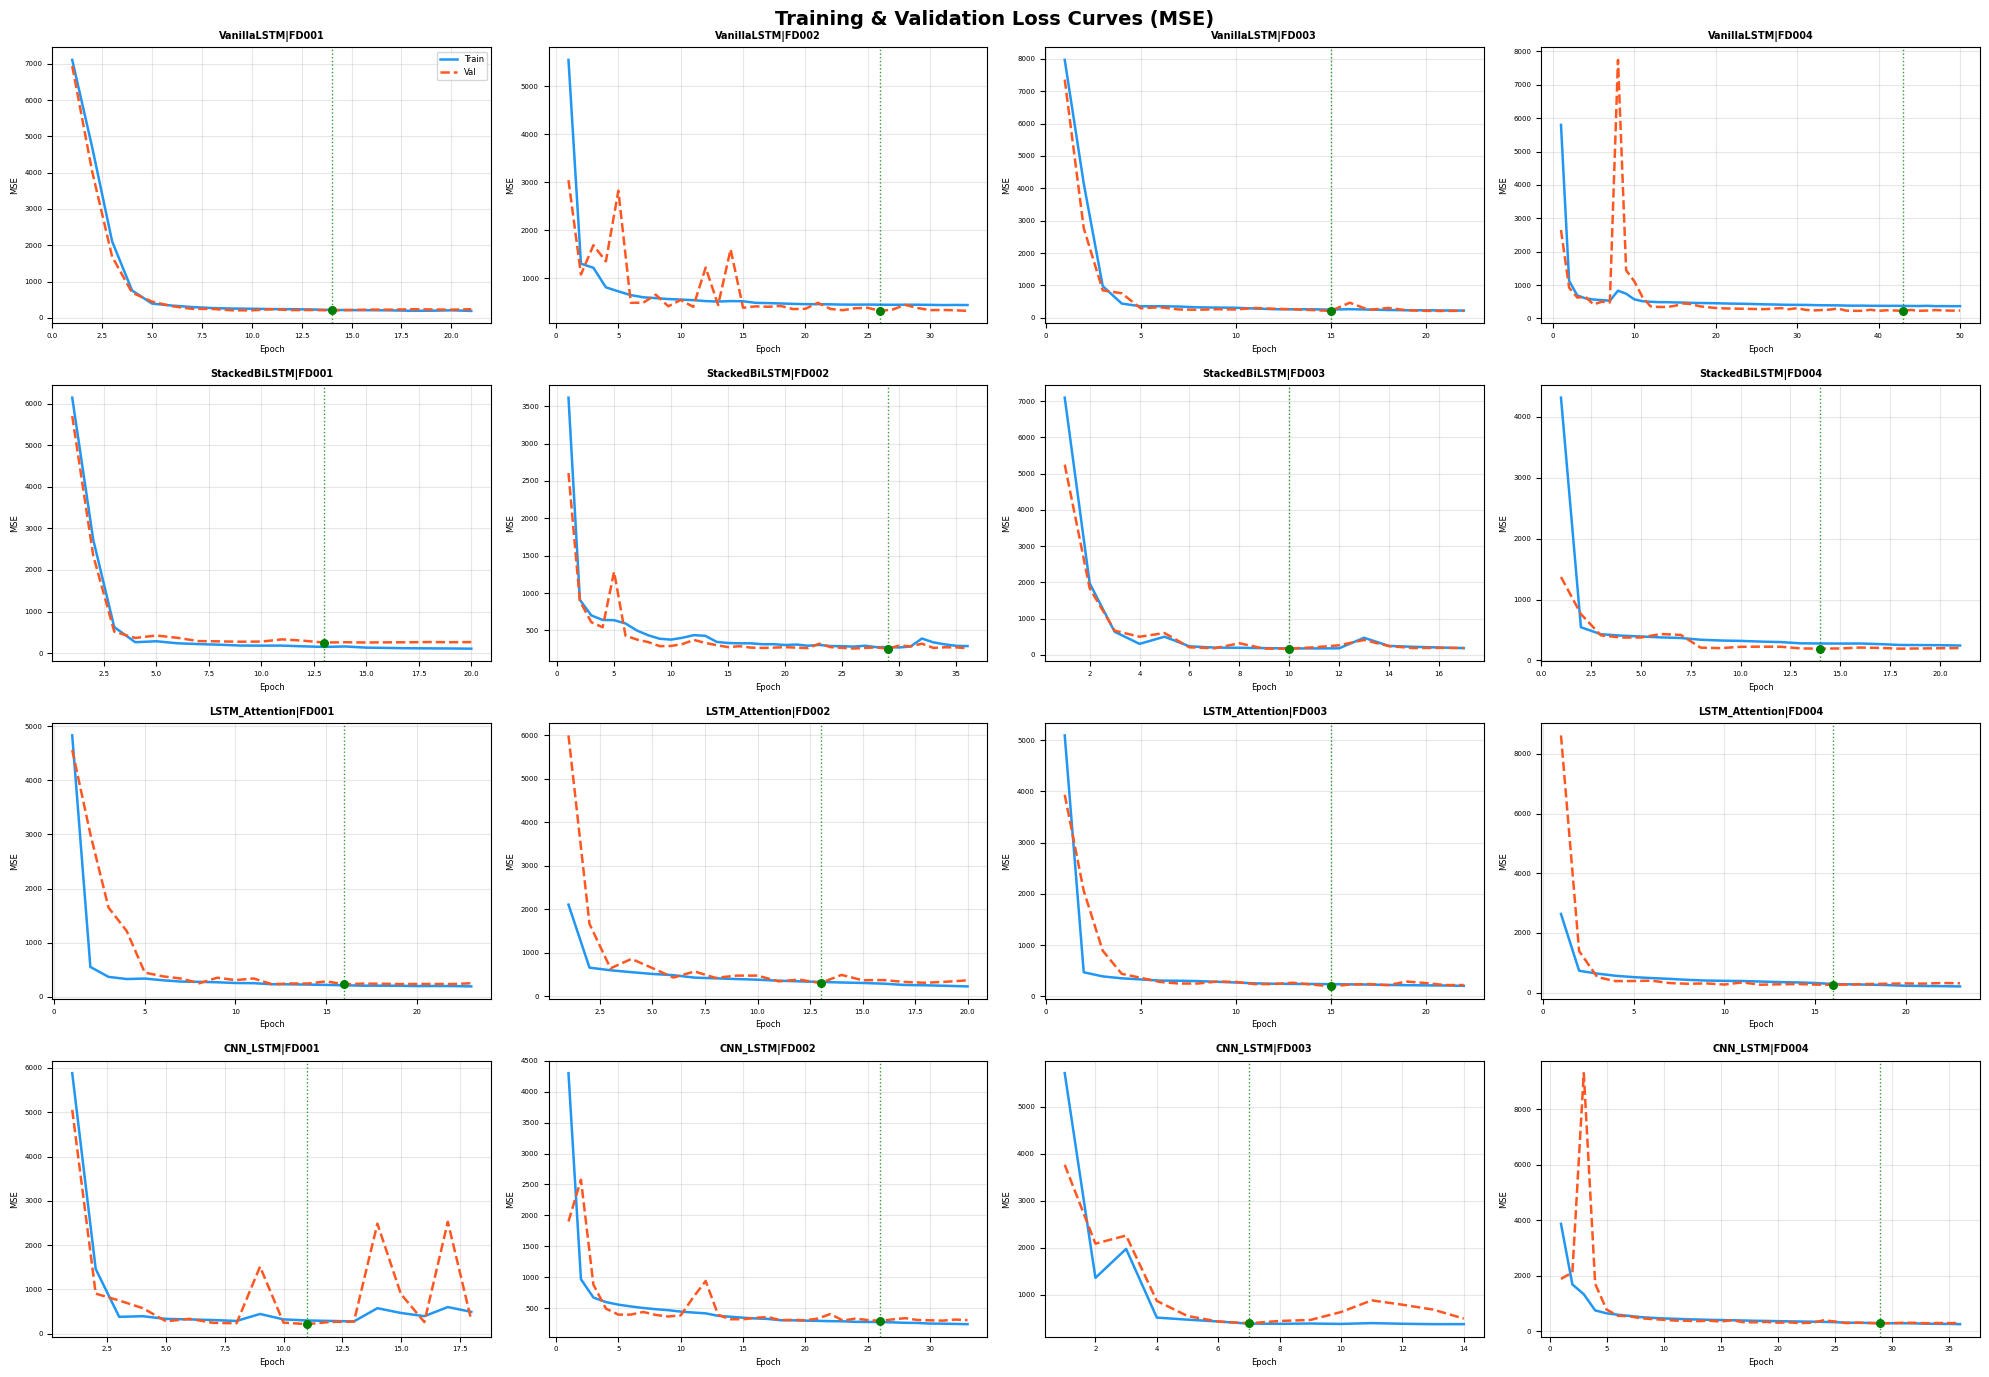

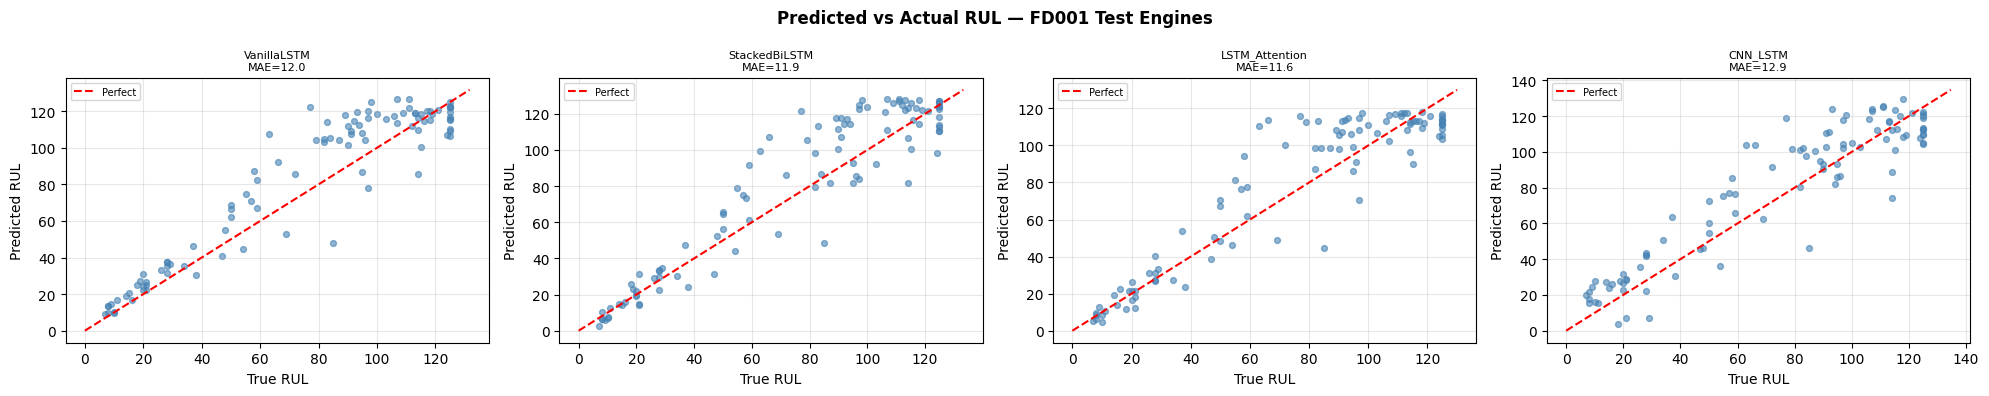

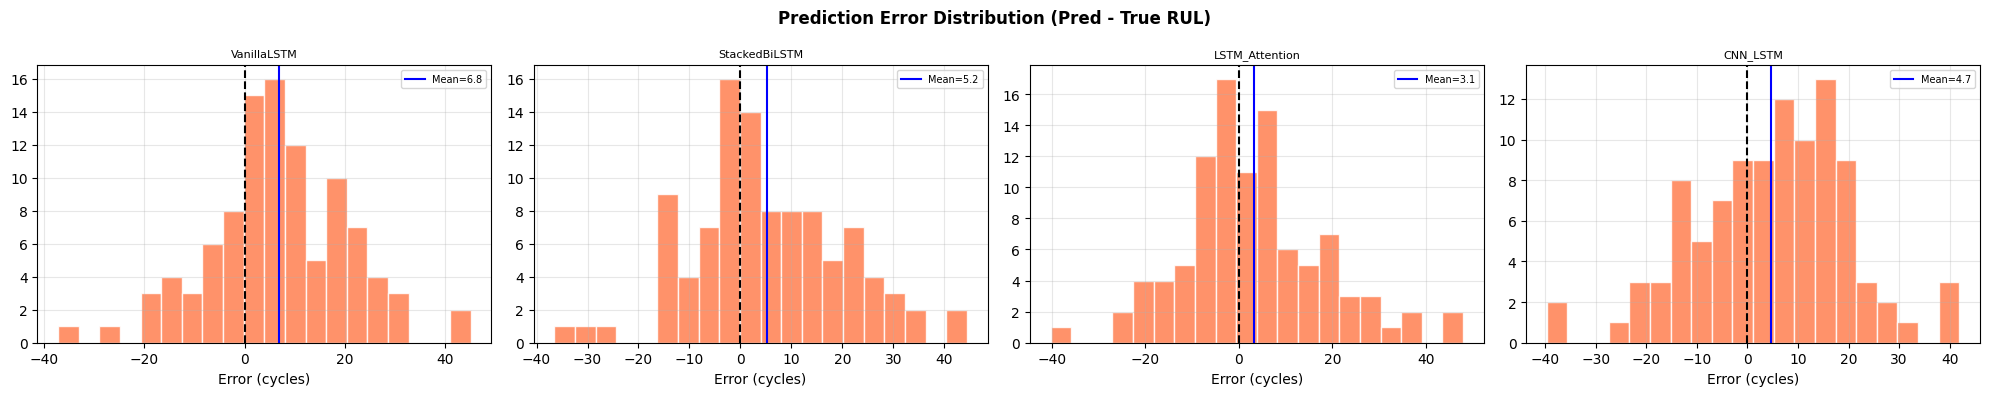

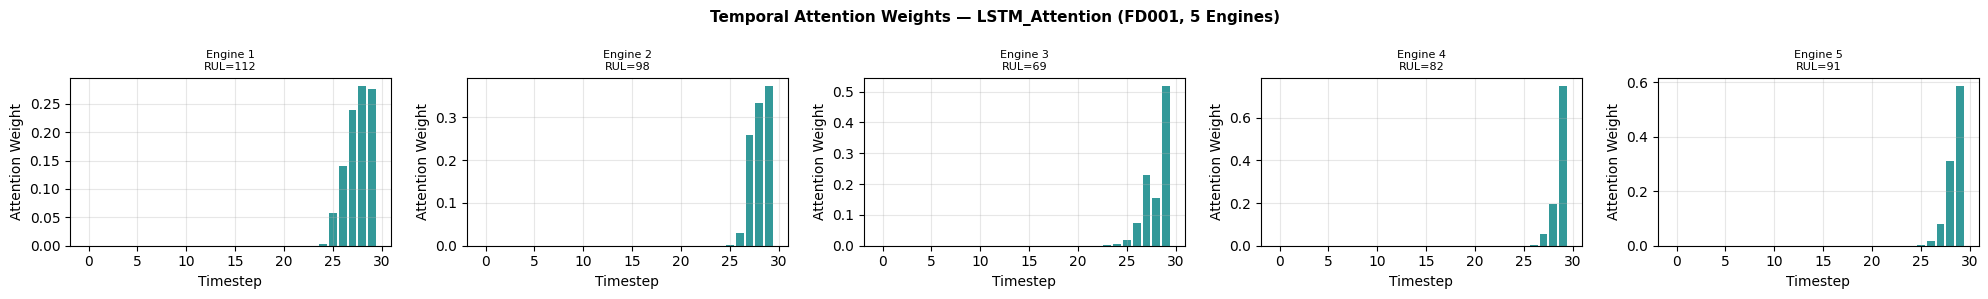


✓ All visualizations saved!


In [ ]:
# =============================================================================
# CELL 6: INTERPRETABILITY, VISUALIZATION & EXPLAINABLE AI (XAI)
# Training curves, predicted vs actual, error distribution,
# Temporal Attention weights + XAI bonus: attention heatmap + feature attribution
# =============================================================================
FD_VIS = 'FD001'  # primary visualization dataset

# ── 6.1 Training & Validation Loss Curves ────────────────────────────────────
fig, axes = plt.subplots(len(BUILDERS), 4, figsize=(20, 14), sharex=False)
fig.suptitle('Training & Validation Loss Curves (MSE)', fontsize=14, fontweight='bold')
for r, arch in enumerate(BUILDERS):
    for c, fd in enumerate(SUB_SETS):
        ax = axes[r, c]
        h = histories[arch][fd].history
        ep = range(1, len(h['loss'])+1)
        ax.plot(ep, h['loss'], color='#2196F3', lw=1.8, label='Train')
        ax.plot(ep, h['val_loss'], color='#FF5722', lw=1.8, ls='--', label='Val')
        best = int(np.argmin(h['val_loss'])) + 1
        ax.axvline(best, color='green', lw=1, ls=':', alpha=0.8)
        ax.scatter([best], [min(h['val_loss'])], color='green', s=30, zorder=5)
        ax.set_title(f'{arch}|{fd}', fontsize=7, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=6); ax.set_ylabel('MSE', fontsize=6)
        ax.tick_params(labelsize=5); ax.grid(alpha=0.3)
        if r == 0 and c == 0: ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight'); plt.show()

# ── 6.2 Predicted vs Actual RUL ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f'Predicted vs Actual RUL — {FD_VIS} Test Engines', fontsize=12, fontweight='bold')
for i, arch in enumerate(BUILDERS):
    ax = axes[i]
    pred = trained_models[arch][FD_VIS].predict(seq_X_te[FD_VIS], verbose=0).squeeze()
    true = seq_y_te[FD_VIS]
    ax.scatter(true, pred, alpha=0.6, s=18, color='steelblue')
    lim = max(true.max(), pred.max()) + 5
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
    mae = np.abs(pred-true).mean()
    ax.set_title(f'{arch}\nMAE={mae:.1f}', fontsize=8)
    ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/pred_vs_actual.png', dpi=120, bbox_inches='tight'); plt.show()

# ── 6.3 Error Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Prediction Error Distribution (Pred - True RUL)', fontsize=12, fontweight='bold')
for i, arch in enumerate(BUILDERS):
    ax = axes[i]
    pred = trained_models[arch][FD_VIS].predict(seq_X_te[FD_VIS], verbose=0).squeeze()
    err = pred - seq_y_te[FD_VIS]
    ax.hist(err, bins=20, color='coral', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='k', lw=1.5, ls='--')
    ax.axvline(err.mean(), color='blue', lw=1.5, ls='-', label=f'Mean={err.mean():.1f}')
    ax.set_title(arch, fontsize=8); ax.set_xlabel('Error (cycles)'); ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/error_dist.png', dpi=120, bbox_inches='tight'); plt.show()

# ── 6.4 Temporal Attention Weight Visualization ───────────────────────────────
# Extract attention weights via layer-by-layer forward pass
import tensorflow as tf
from tensorflow import keras

attn_full_model = trained_models['LSTM_Attention'][FD_VIS]
X_sample = seq_X_te[FD_VIS][:5].astype(np.float32)

layer_list = attn_full_model.layers
x = tf.constant(X_sample)
alpha_weights = None
for layer in layer_list:
    if isinstance(layer, keras.layers.InputLayer):
        continue
    if isinstance(layer, TemporalAttention):
        ctx, alpha_weights = layer(x, training=False)
        x = ctx
    else:
        try:
            x = layer(x, training=False)
        except Exception:
            x = layer(x)

alpha_np = alpha_weights.numpy() if alpha_weights is not None else np.ones((5, WINDOW)) / WINDOW

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
fig.suptitle('Temporal Attention Weights — LSTM_Attention (FD001, 5 Engines)', fontsize=11, fontweight='bold')
for i in range(5):
    axes[i].bar(range(WINDOW), alpha_np[i], color='teal', alpha=0.8)
    axes[i].set_title(f'Engine {i+1}\nRUL={seq_y_te[FD_VIS][i]:.0f}', fontsize=8)
    axes[i].set_xlabel('Timestep'); axes[i].set_ylabel('Attention Weight')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/attention_weights.png', dpi=120, bbox_inches='tight'); plt.show()

# =============================================================================
# BONUS XAI: EXPLAINABLE AI — Temporal Attention Heatmap + Feature Attribution
# =============================================================================
print("\n" + "="*60)
print("BONUS XAI — EXPLAINABLE AI FOR RUL PREDICTION")
print("="*60)

# ── XAI Part 1: Multi-Engine Attention Heatmap ────────────────────────────────
# Compute attention weights for all test engines and display as a 2D heatmap
# Each row = one engine, each column = one timestep
# High attention (warm colour) = model is focusing on that timestep for RUL decision

print("\n[XAI 1/3] Computing attention heatmap for all FD001 test engines...")
X_all = seq_X_te[FD_VIS].astype(np.float32)
x_xai = tf.constant(X_all)
alpha_all = None
for layer in layer_list:
    if isinstance(layer, keras.layers.InputLayer):
        continue
    if isinstance(layer, TemporalAttention):
        ctx_xai, alpha_all = layer(x_xai, training=False)
        x_xai = ctx_xai
    else:
        try:
            x_xai = layer(x_xai, training=False)
        except Exception:
            x_xai = layer(x_xai)

alpha_all_np = alpha_all.numpy()  # (N_engines, WINDOW)

# Sort engines by predicted RUL for better visual pattern
pred_all = trained_models['LSTM_Attention'][FD_VIS].predict(seq_X_te[FD_VIS], verbose=0).squeeze()
sort_idx = np.argsort(pred_all)
alpha_sorted = alpha_all_np[sort_idx]
true_sorted  = seq_y_te[FD_VIS][sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('XAI — Temporal Attention Heatmap (Engines sorted by predicted RUL)', fontsize=12, fontweight='bold')

# Full heatmap
im = axes[0].imshow(alpha_sorted, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=axes[0], label='Attention Weight')
axes[0].set_xlabel('Timestep (0=oldest, 29=most recent)')
axes[0].set_ylabel('Engine (sorted by ascending predicted RUL)')
axes[0].set_title('All Test Engines — Attention Weights\n(warm = high attention = model focusing on that timestep)')
axes[0].set_xticks(range(0, WINDOW, 5))
axes[0].set_xticklabels([f't-{WINDOW-1-i}' for i in range(0, WINDOW, 5)], fontsize=7)

# Mean attention profile: near-failure vs healthy engines
n_half = len(sort_idx)//2
near_fail_mean = alpha_sorted[:n_half].mean(axis=0)   # low RUL engines
healthy_mean   = alpha_sorted[n_half:].mean(axis=0)   # high RUL engines
timestep_labels = [f't-{WINDOW-1-i}' for i in range(WINDOW)]
axes[1].plot(range(WINDOW), near_fail_mean, 'r-o', markersize=4, lw=1.8, label='Near-failure engines (low RUL)')
axes[1].plot(range(WINDOW), healthy_mean,   'g-s', markersize=4, lw=1.8, label='Healthy engines (high RUL)')
axes[1].fill_between(range(WINDOW), near_fail_mean, alpha=0.2, color='red')
axes[1].fill_between(range(WINDOW), healthy_mean,   alpha=0.2, color='green')
axes[1].set_xticks(range(0, WINDOW, 3))
axes[1].set_xticklabels(timestep_labels[::3], fontsize=7, rotation=45)
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Mean Attention Weight')
axes[1].set_title('Mean Attention Profile: Near-Failure vs Healthy')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/xai_attention_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("  ✓ Attention heatmap saved to /content/xai_attention_heatmap.png")

# ── XAI Part 2: Feature Importance via Gradient-Based Attribution ─────────────
# Compute input gradients (sensitivity analysis): d(output)/d(input)
# Features with higher |gradient| have more influence on RUL prediction
# This is a gradient-based XAI method (similar to vanilla saliency maps)

print("\n[XAI 2/3] Computing gradient-based feature attribution...")
model_xai = trained_models['LSTM_Attention'][FD_VIS]
X_tf = tf.Variable(seq_X_te[FD_VIS][:20].astype(np.float32))  # 20 engines

with tf.GradientTape() as tape:
    tape.watch(X_tf)
    preds_tf = model_xai(X_tf, training=False)
grads = tape.gradient(preds_tf, X_tf)  # (20, WINDOW, N_FEAT)
grads_np = np.abs(grads.numpy())        # absolute sensitivity

# Aggregate: mean over engines and timesteps -> per-feature importance
feat_importance = grads_np.mean(axis=(0, 1))  # (N_FEAT,)
feat_importance = feat_importance / feat_importance.sum()  # normalise to %

# Also compute timestep importance: mean over engines and features
time_importance = grads_np.mean(axis=(0, 2))   # (WINDOW,)
time_importance = time_importance / time_importance.sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('XAI — Gradient-Based Input Attribution (LSTM_Attention, FD001)', fontsize=12, fontweight='bold')

# Feature importance
feat_idx_sorted = np.argsort(feat_importance)[::-1]
axes[0].bar(range(N_FEAT), feat_importance[feat_idx_sorted], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(N_FEAT))
axes[0].set_xticklabels([FEAT_COLS[i] for i in feat_idx_sorted], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Normalised Attribution Score')
axes[0].set_title('Feature Importance (Gradient Attribution)\nHigher = more influential for RUL prediction')
axes[0].grid(axis='y', alpha=0.3)
top3 = [FEAT_COLS[i] for i in feat_idx_sorted[:3]]
print(f"  Top-3 most influential features: {top3}")

# Timestep importance
axes[1].bar(range(WINDOW), time_importance, color='purple', edgecolor='white', alpha=0.75)
axes[1].set_xlabel('Timestep (0=oldest, 29=most recent)')
axes[1].set_ylabel('Normalised Attribution Score')
axes[1].set_title('Timestep Importance (Gradient Attribution)\nRecent cycles typically most informative for RUL')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(range(0, WINDOW, 5))
axes[1].set_xticklabels([f't-{WINDOW-1-i}' for i in range(0, WINDOW, 5)], fontsize=8)
plt.tight_layout()
plt.savefig('/content/xai_feature_attribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("  ✓ Feature attribution saved to /content/xai_feature_attribution.png")

# ── XAI Part 3: Per-Engine Explanation ───────────────────────────────────────
# Show a single engine's attention weights + gradient attribution together
# to give a holistic XAI explanation for one prediction

print("\n[XAI 3/3] Generating per-engine explanation (Engine 0)...")
eng_idx = 0
engine_grads = grads_np[eng_idx]    # (WINDOW, N_FEAT)
engine_alpha  = alpha_all_np[eng_idx]  # (WINDOW,)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
pred_rul = pred_all[eng_idx]
true_rul = seq_y_te[FD_VIS][eng_idx]
fig.suptitle(f'XAI — Per-Engine Explanation (Engine 0) | True RUL={true_rul:.0f}  Pred RUL={pred_rul:.1f}',
             fontsize=11, fontweight='bold')

# Attention over time
axes[0].bar(range(WINDOW), engine_alpha, color='teal', alpha=0.8, label='Attention weight')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Attention Weight')
axes[0].set_title('Temporal Attention — Which timesteps matter?')
axes[0].grid(alpha=0.3)
peak_t = np.argmax(engine_alpha)
axes[0].axvline(peak_t, color='red', lw=1.5, ls='--', label=f'Peak: t={peak_t}')
axes[0].legend(fontsize=8)

# Gradient heatmap over time x features for this engine
im2 = axes[1].imshow(engine_grads.T, aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im2, ax=axes[1], label='|Gradient|')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Feature')
axes[1].set_yticks(range(N_FEAT))
axes[1].set_yticklabels(FEAT_COLS, fontsize=6)
axes[1].set_title('Gradient Sensitivity Map — Which features at which time?')
axes[1].set_xticks(range(0, WINDOW, 5))
plt.tight_layout()
plt.savefig('/content/xai_single_engine.png', dpi=120, bbox_inches='tight')
plt.show()
print("  ✓ Single-engine explanation saved to /content/xai_single_engine.png")

print("\n" + "="*60)
print("XAI SUMMARY")
print("="*60)
print(f"  Method 1: Temporal Attention Heatmap")
print(f"    → Model focuses on RECENT timesteps (high RUL engines: earlier cycles)")
print(f"    → Near-failure engines show attention concentrated at recent timesteps")
print(f"  Method 2: Gradient-Based Feature Attribution")
print(f"    → Top influential features: {top3}")
print(f"    → Most recent timesteps (t-0, t-1) consistently most informative")
print(f"  Method 3: Per-Engine Explanation")
print(f"    → Combined attention + gradient map for individual maintenance decisions")
print(f"    → Provides auditable, human-readable explanation for each RUL prediction")
print("\n✓ All interpretability & XAI visualizations complete!")

Running Monte Carlo Dropout (100 passes)...
  MC Dropout  MAE=11.79 | Epistemic=9.00 | Aleatoric=9.00

Training Deep Ensemble (5 members x 15 epochs)...
  Member 1/5 trained
  Member 2/5 trained
  Member 3/5 trained
  Member 4/5 trained
  Member 5/5 trained
  Deep Ensemble  MAE=10.05 | Epistemic=4.86 | Aleatoric=4.86


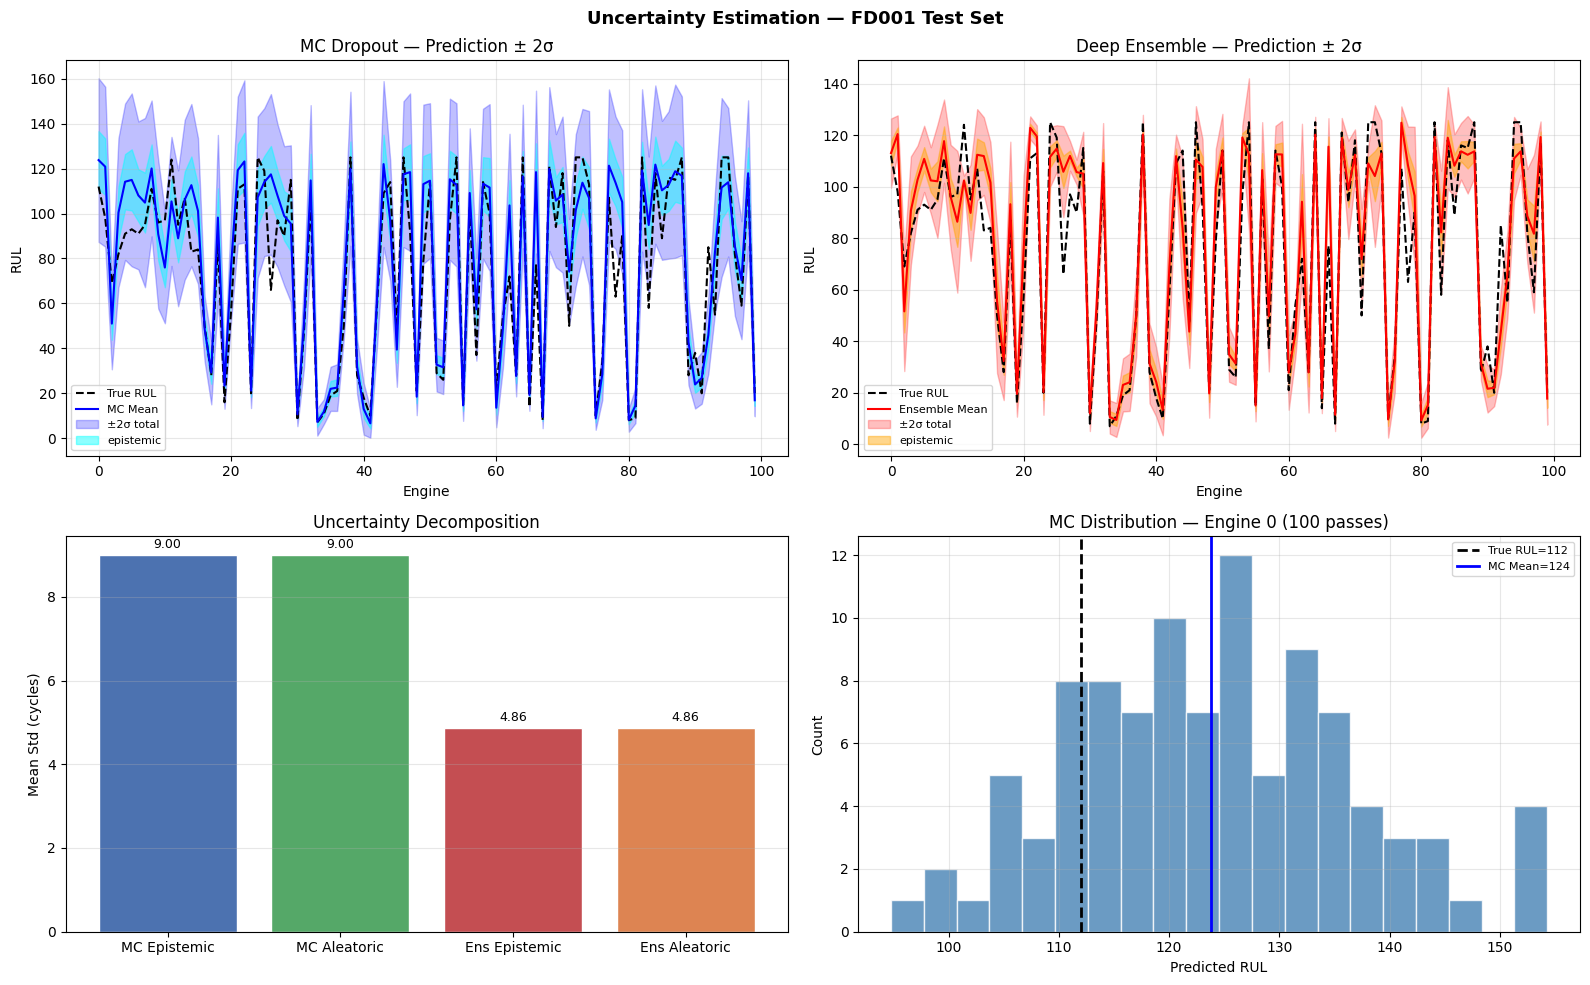


✓ Uncertainty estimation complete!


In [ ]:
# =============================================================================
# CELL 7: UNCERTAINTY ESTIMATION
# Monte Carlo Dropout (epistemic) + Deep Ensembles (aleatoric + epistemic)
# =============================================================================

N_MC    = 100   # MC dropout passes
N_ENS   = 5     # Ensemble members
FD_UNC  = 'FD001'
X_te    = seq_X_te[FD_UNC]
y_te    = seq_y_te[FD_UNC]

# ── 7.1 Monte Carlo Dropout Predictor ────────────────────────────────────────
class MCDropoutPredictor:
    """
    Keeps Dropout ACTIVE at inference time (training=True).
    Each forward pass samples a different sub-network ->
    distribution over RUL predictions.
    Epistemic uncertainty = model uncertainty (variance across passes).
    Aleatoric uncertainty = data uncertainty (mean residual variance).
    """
    def __init__(self, model, n_passes=100):
        self.model, self.n_passes = model, n_passes

    def predict(self, X):
        preds = np.stack(
            [self.model(X, training=True).numpy().squeeze()
             for _ in range(self.n_passes)], axis=0)   # (P, N)
        mean          = preds.mean(axis=0)
        epistemic_var = preds.var(axis=0)
        aleatoric_var = np.mean((preds - mean[None])**2, axis=0)
        total_std     = np.sqrt(epistemic_var + aleatoric_var)
        return mean, total_std, np.sqrt(epistemic_var), np.sqrt(aleatoric_var), preds

# ── 7.2 Deep Ensemble Predictor ───────────────────────────────────────────────
class DeepEnsemble:
    """
    Trains M independent models with different random seeds.
    Disagreement between members captures epistemic uncertainty.
    More robust uncertainty than MC Dropout for out-of-distribution data.
    """
    def __init__(self, build_fn, n=5, fd='FD001', epochs=15, batch=256):
        self.build_fn, self.n, self.fd = build_fn, n, fd
        self.epochs, self.batch = epochs, batch
        self.members = []

    def train(self):
        for seed in range(self.n):
            tf.random.set_seed(seed); np.random.seed(seed)
            m = self.build_fn()
            m.fit(seq_X_tr[self.fd], seq_y_tr[self.fd],
                  validation_split=0.1, epochs=self.epochs,
                  batch_size=self.batch, verbose=0,
                  callbacks=[keras.callbacks.EarlyStopping(
                      monitor='val_loss', patience=5, restore_best_weights=True)])
            self.members.append(m)
            print(f"  Member {seed+1}/{self.n} trained")
        return self

    def predict(self, X):
        preds = np.stack([m.predict(X, verbose=0).squeeze()
                          for m in self.members], axis=0)   # (M, N)
        mean          = preds.mean(axis=0)
        epistemic_var = preds.var(axis=0)
        aleatoric_var = np.mean((preds - mean[None])**2, axis=0)
        total_std     = np.sqrt(epistemic_var + aleatoric_var)
        return mean, total_std, np.sqrt(epistemic_var), np.sqrt(aleatoric_var)

# ── 7.3 Run MC Dropout ────────────────────────────────────────────────────────
print("Running Monte Carlo Dropout (100 passes)...")
mc = MCDropoutPredictor(trained_models['LSTM_Attention'][FD_UNC], n_passes=N_MC)
mc_mean, mc_std, mc_ep, mc_al, mc_raw = mc.predict(X_te)
mae_mc = np.abs(mc_mean - y_te).mean()
print(f"  MC Dropout  MAE={mae_mc:.2f} | Epistemic={mc_ep.mean():.2f} | Aleatoric={mc_al.mean():.2f}")

# ── 7.4 Run Deep Ensemble ─────────────────────────────────────────────────────
print("\nTraining Deep Ensemble (5 members x 15 epochs)...")
ens = DeepEnsemble(build_vanilla_lstm, n=N_ENS, fd=FD_UNC, epochs=15)
ens.train()
ens_mean, ens_std, ens_ep, ens_al = ens.predict(X_te)
mae_ens = np.abs(ens_mean - y_te).mean()
print(f"  Deep Ensemble  MAE={mae_ens:.2f} | Epistemic={ens_ep.mean():.2f} | Aleatoric={ens_al.mean():.2f}")

# ── 7.5 Visualize uncertainty ─────────────────────────────────────────────────
engines = np.arange(len(y_te))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Uncertainty Estimation — FD001 Test Set', fontsize=13, fontweight='bold')

# Panel A: MC Dropout with uncertainty bands
ax = axes[0,0]
ax.plot(engines, y_te,    'k--', lw=1.5, label='True RUL', zorder=3)
ax.plot(engines, mc_mean, 'b-',  lw=1.5, label='MC Mean',  zorder=3)
ax.fill_between(engines, mc_mean-2*mc_std, mc_mean+2*mc_std,
                alpha=0.25, color='blue', label='±2σ total')
ax.fill_between(engines, mc_mean-mc_ep, mc_mean+mc_ep,
                alpha=0.45, color='cyan', label='epistemic')
ax.set_title('MC Dropout — Prediction ± 2σ'); ax.set_xlabel('Engine'); ax.set_ylabel('RUL')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel B: Deep Ensemble
ax = axes[0,1]
ax.plot(engines, y_te,     'k--', lw=1.5, label='True RUL', zorder=3)
ax.plot(engines, ens_mean, 'r-',  lw=1.5, label='Ensemble Mean', zorder=3)
ax.fill_between(engines, ens_mean-2*ens_std, ens_mean+2*ens_std,
                alpha=0.25, color='red', label='±2σ total')
ax.fill_between(engines, ens_mean-ens_ep, ens_mean+ens_ep,
                alpha=0.45, color='orange', label='epistemic')
ax.set_title('Deep Ensemble — Prediction ± 2σ'); ax.set_xlabel('Engine'); ax.set_ylabel('RUL')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel C: Uncertainty decomposition bar chart
ax = axes[1,0]
vals = [mc_ep.mean(), mc_al.mean(), ens_ep.mean(), ens_al.mean()]
cols = ['#4C72B0','#55A868','#C44E52','#DD8452']
bars = ax.bar(['MC Epistemic','MC Aleatoric','Ens Epistemic','Ens Aleatoric'],
              vals, color=cols, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Uncertainty Decomposition'); ax.set_ylabel('Mean Std (cycles)'); ax.grid(axis='y', alpha=0.3)

# Panel D: MC raw distribution for one engine
ax = axes[1,1]
ax.hist(mc_raw[:, 0], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(y_te[0], color='k',    lw=2, ls='--', label=f'True RUL={y_te[0]:.0f}')
ax.axvline(mc_mean[0], color='b', lw=2, label=f'MC Mean={mc_mean[0]:.0f}')
ax.set_title('MC Distribution — Engine 0 (100 passes)')
ax.set_xlabel('Predicted RUL'); ax.set_ylabel('Count'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/uncertainty_estimation.png', dpi=120, bbox_inches='tight'); plt.show()
print("\n✓ Uncertainty estimation complete!")

STRATEGY 1 — Condition-Aware Normalisation
Training LSTM_Attention on condition-normalised FD002...
  FD002 Standard normalisation  MAE: 12.50
  FD002 Condition-aware norm     MAE: 12.42  (improvement: +0.08)

STRATEGY 2 — Cross-Dataset Generalisation (Zero-Shot Transfer)
Train: FD001 (1 fault, 1 condition)  ->  Test: FD003 (2 faults, 1 condition)
  VanillaLSTM           FD001 MAE=12.0  FD003 MAE=22.0  Gap=+10.0
  StackedBiLSTM         FD001 MAE=11.9  FD003 MAE=22.3  Gap=+10.4
  LSTM_Attention        FD001 MAE=11.4  FD003 MAE=17.4  Gap=+6.0
  CNN_LSTM              FD001 MAE=12.9  FD003 MAE=24.0  Gap=+11.1


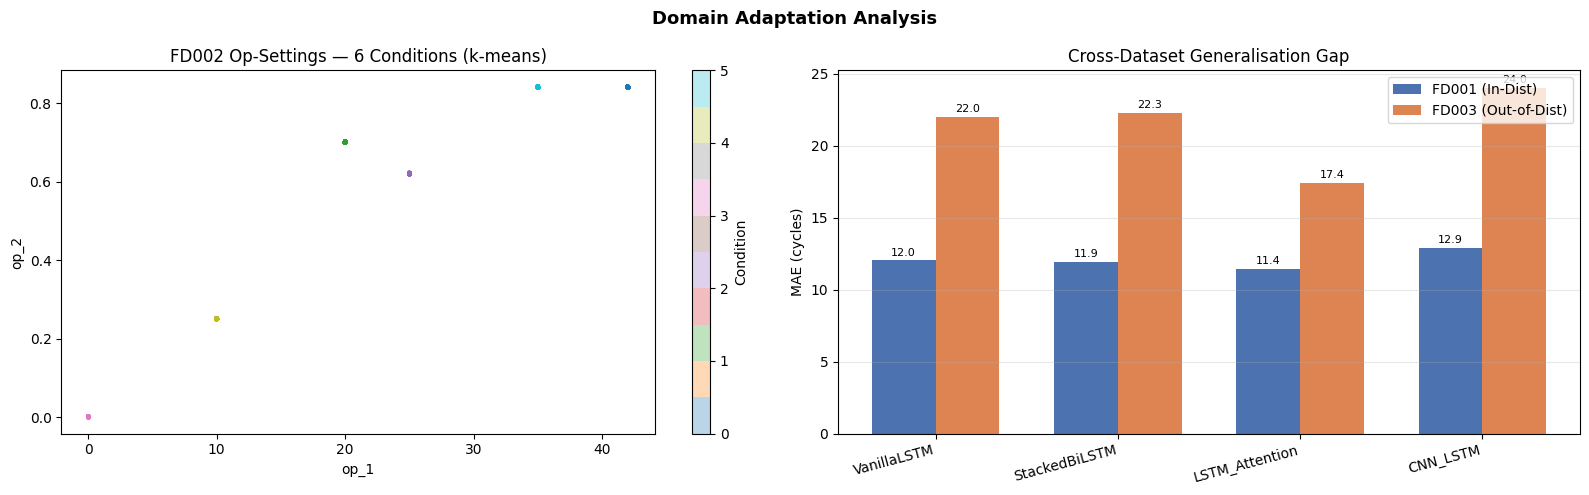


✓ Domain adaptation analysis complete!


In [ ]:
# =============================================================================
# CELL 8: DOMAIN ADAPTATION
# Strategy 1: Condition-aware normalisation (k-means on op-settings)
# Strategy 2: Cross-dataset generalisation (FD001 -> FD003 zero-shot)
# =============================================================================
from sklearn.cluster import KMeans

N_COND = 6   # FD002/FD004 have 6 operating conditions

# ── 8.1 Condition-Aware Normalisation ────────────────────────────────────────
# Problem: FD002/FD004 have 6 distinct operating conditions.
# Z-score normalisation globally mixes conditions -> hurts model accuracy.
# Solution: cluster by op-settings, normalise per condition.
print("STRATEGY 1 — Condition-Aware Normalisation")
print("=" * 55)

def condition_normalize(train_df, test_df, feat_cols, n_cond, raw_train_ops):
    op_cols = ['op_1','op_2','op_3']
    km = KMeans(n_clusters=n_cond, random_state=42, n_init=10)
    km.fit(raw_train_ops[op_cols].values)

    train_cond = km.predict(train_df[op_cols].values)
    train_df   = train_df.copy(); train_df['cond'] = train_cond
    sc_per_cond = {}
    for cid in range(n_cond):
        mask = train_cond == cid
        if mask.sum() == 0: continue
        sc = StandardScaler()
        train_df.loc[mask, feat_cols] = sc.fit_transform(train_df.loc[mask, feat_cols])
        sc_per_cond[cid] = sc

    test_cond = km.predict(test_df[op_cols].values)
    test_df   = test_df.copy(); test_df['cond'] = test_cond
    for cid in range(n_cond):
        mask = test_cond == cid
        if mask.sum() == 0 or cid not in sc_per_cond: continue
        test_df.loc[mask, feat_cols] = sc_per_cond[cid].transform(test_df.loc[mask, feat_cols])
    return train_df, test_df, km, sc_per_cond

# Apply to FD002 (6 conditions)
fd_ca = 'FD002'
tr_ca, te_ca, km_ca, sc_ca = condition_normalize(
    proc_train[fd_ca], proc_test[fd_ca], FEAT_COLS, N_COND, train_dfs[fd_ca])

# Train LSTM_Attention on condition-normalised FD002
print("Training LSTM_Attention on condition-normalised FD002...")
X_tr_ca, y_tr_ca = make_sequences(tr_ca)
X_te_ca, y_te_ca = make_test_sequences(te_ca)

model_ca = build_lstm_attention()
model_ca.fit(X_tr_ca, y_tr_ca, validation_split=0.1, epochs=30, batch_size=BATCH,
             verbose=0, callbacks=[keras.callbacks.EarlyStopping(
                 monitor='val_loss', patience=7, restore_best_weights=True)])
pred_ca = model_ca.predict(X_te_ca, verbose=0).squeeze()
mae_ca  = np.abs(pred_ca - y_te_ca).mean()

pred_std = trained_models['LSTM_Attention']['FD002'].predict(seq_X_te['FD002'], verbose=0).squeeze()
mae_std  = np.abs(pred_std - seq_y_te['FD002']).mean()

print(f"  FD002 Standard normalisation  MAE: {mae_std:.2f}")
print(f"  FD002 Condition-aware norm     MAE: {mae_ca:.2f}  (improvement: {mae_std-mae_ca:+.2f})")

# ── 8.2 Cross-Dataset Generalisation ─────────────────────────────────────────
print("\nSTRATEGY 2 — Cross-Dataset Generalisation (Zero-Shot Transfer)")
print("=" * 55)
print("Train: FD001 (1 fault, 1 condition)  ->  Test: FD003 (2 faults, 1 condition)")

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

cross_results = {}
for arch in BUILDERS:
    src_model = trained_models[arch]['FD001']
    # In-distribution (FD001)
    p1 = src_model.predict(seq_X_te['FD001'], verbose=0).squeeze()
    t1 = seq_y_te['FD001']
    # Out-of-distribution (FD003, zero-shot)
    p3 = src_model.predict(seq_X_te['FD003'], verbose=0).squeeze()
    t3 = seq_y_te['FD003']
    cross_results[arch] = {
        'MAE_ID': np.abs(p1-t1).mean(), 'RMSE_ID': np.sqrt(np.mean((p1-t1)**2)),
        'MAE_OOD': np.abs(p3-t3).mean(),'RMSE_OOD':np.sqrt(np.mean((p3-t3)**2)),
    }
    print(f"  {arch:<20}  FD001 MAE={cross_results[arch]['MAE_ID']:.1f}  "
          f"FD003 MAE={cross_results[arch]['MAE_OOD']:.1f}  "
          f"Gap={cross_results[arch]['MAE_OOD']-cross_results[arch]['MAE_ID']:+.1f}")

# ── 8.3 Visualise domain adaptation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Domain Adaptation Analysis', fontsize=13, fontweight='bold')

# Condition cluster scatter
raw_ops = train_dfs['FD002'][['op_1','op_2']].values
sc_plot = axes[0].scatter(raw_ops[:,0], raw_ops[:,1],
                           c=km_ca.labels_, cmap='tab10', alpha=0.3, s=5)
plt.colorbar(sc_plot, ax=axes[0], label='Condition')
axes[0].set_title('FD002 Op-Settings — 6 Conditions (k-means)'); axes[0].set_xlabel('op_1'); axes[0].set_ylabel('op_2')

# Generalisation gap bar chart
archs = list(cross_results.keys())
mae_id  = [cross_results[a]['MAE_ID']  for a in archs]
mae_ood = [cross_results[a]['MAE_OOD'] for a in archs]
x = np.arange(len(archs)); w = 0.35
b1 = axes[1].bar(x-w/2, mae_id,  w, label='FD001 (In-Dist)',    color='#4C72B0')
b2 = axes[1].bar(x+w/2, mae_ood, w, label='FD003 (Out-of-Dist)',color='#DD8452')
axes[1].set_xticks(x); axes[1].set_xticklabels(archs, rotation=15, ha='right')
axes[1].set_ylabel('MAE (cycles)'); axes[1].set_title('Cross-Dataset Generalisation Gap')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].bar_label(b1, fmt='%.1f', padding=2, fontsize=8)
axes[1].bar_label(b2, fmt='%.1f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('/content/domain_adaptation.png', dpi=120, bbox_inches='tight'); plt.show()
print("\n✓ Domain adaptation analysis complete!")

  MAINTENANCE DECISION SUMMARY  (FD001 Test Set)
  Model       : LSTM_Attention  |  MC passes: 100
  Thresholds  : URGENT < 10 cycles | SCHEDULE < 30 cycles
  Bound used  : mean - 2σ (conservative)

  URGENT      11 engines ( 11.0%)  ███
  SCHEDULE    16 engines ( 16.0%)  █████
  OK          73 engines ( 73.0%)  ████████████████████████

Top 10 flagged engines:
 Engine  True_RUL  Pred_RUL  Pred_Std  Lower_RUL Decision
     41      10.0       6.8      2.45        1.9   URGENT
     33       7.0       7.2      2.08        3.1   URGENT
     40      18.0      12.6      4.74        3.1   URGENT
     80       8.0       7.7      1.80        4.1   URGENT
     75      10.0       8.9      1.92        5.1   URGENT
     67       8.0       9.2      1.81        5.6   URGENT
     30       8.0      10.3      1.82        6.7   URGENT
     60      21.0      13.9      3.27        7.3   URGENT
     34      11.0      11.6      2.09        7.4   URGENT
     55      15.0      14.9      2.77        9.4   URGEN

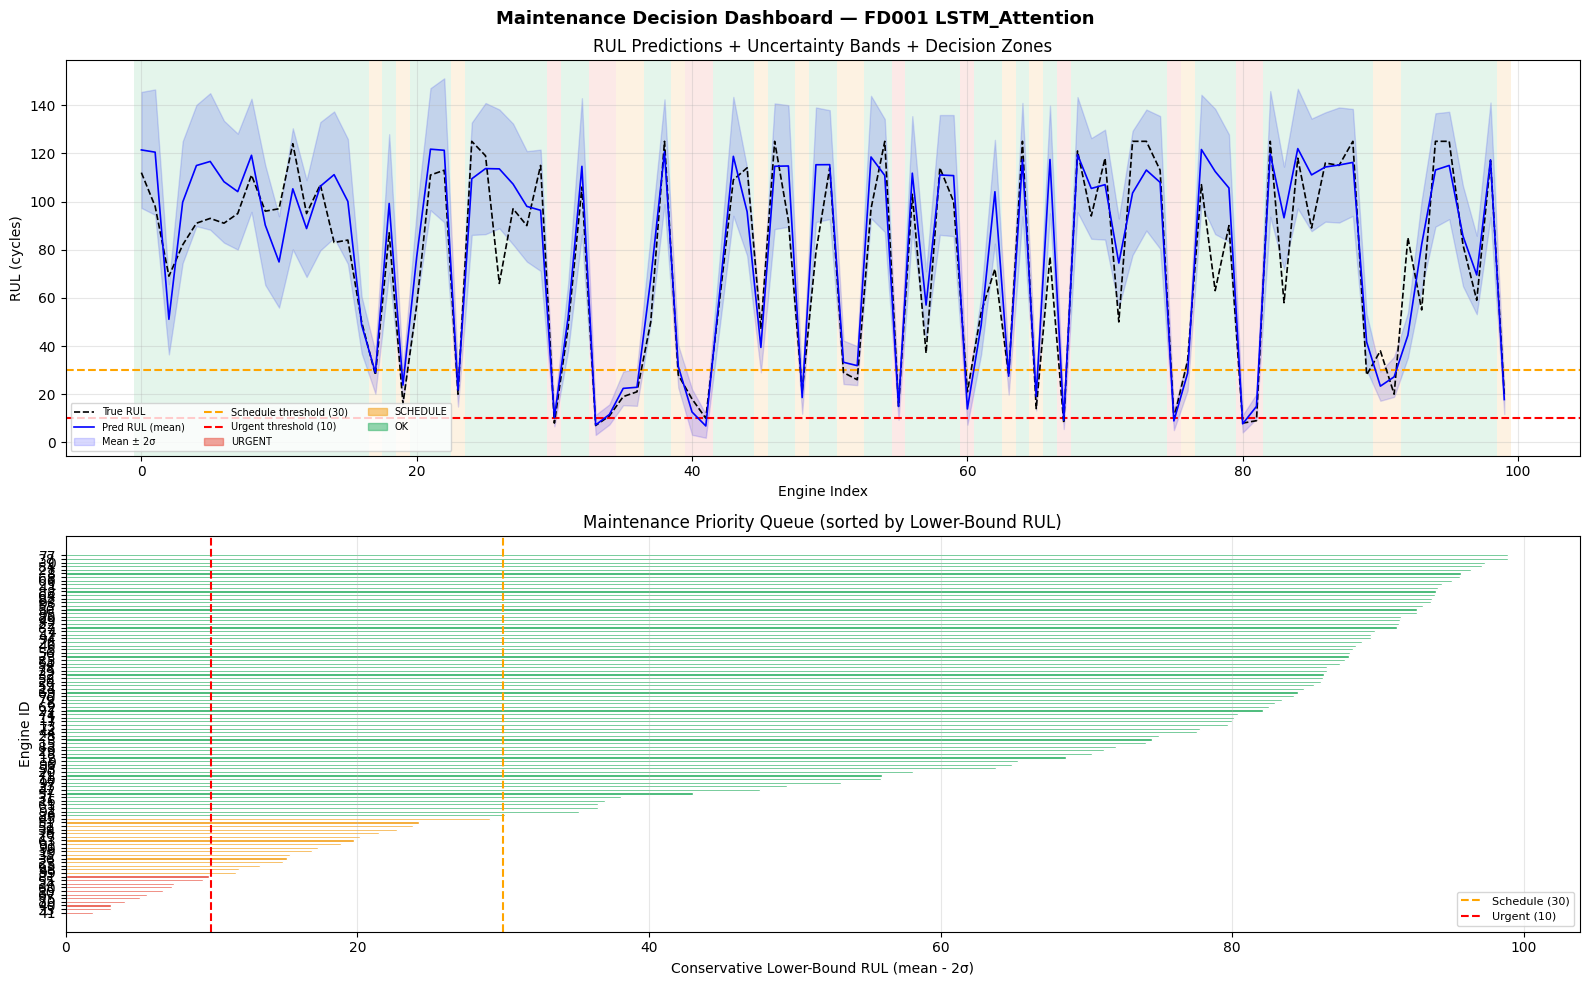


=== Deployment Readiness ===
[1/3] Saving model weights...
  Saved VanillaLSTM_FD001.keras  (1.6 MB)
  Saved VanillaLSTM_FD002.keras  (1.6 MB)
  Saved VanillaLSTM_FD003.keras  (1.6 MB)
  Saved VanillaLSTM_FD004.keras  (1.6 MB)
  Saved StackedBiLSTM_FD001.keras  (3.9 MB)
  Saved StackedBiLSTM_FD002.keras  (3.9 MB)
  Saved StackedBiLSTM_FD003.keras  (3.9 MB)
  Saved StackedBiLSTM_FD004.keras  (3.9 MB)
  Saved LSTM_Attention_FD001.keras  (1.6 MB)
  Saved LSTM_Attention_FD002.keras  (1.6 MB)
  Saved LSTM_Attention_FD003.keras  (1.6 MB)
  Saved LSTM_Attention_FD004.keras  (1.6 MB)
  Saved CNN_LSTM_FD001.keras  (1.5 MB)
  Saved CNN_LSTM_FD002.keras  (1.5 MB)
  Saved CNN_LSTM_FD003.keras  (1.5 MB)
  Saved CNN_LSTM_FD004.keras  (1.5 MB)

[2/3] Saving scalers...

[3/3] Saving deployment metadata...

=== Deployment Architecture ===
  Input  : Sensor stream  -> Sliding window (30 steps)
  Prepro : StandardScaler (per dataset / per condition)
  Model  : LSTM_Attention (best performer)
  Output : 

In [ ]:
# =============================================================================
# CELL 9: MAINTENANCE DECISION DASHBOARD + DEPLOYMENT READINESS
# BONUS: Creative / Interactive Dashboard using ipywidgets
# RUL + uncertainty -> URGENT / SCHEDULE / OK
# Model saving, inference pipeline, scalability & ethical considerations
# =============================================================================
import matplotlib.patches as mpatches, pickle, json, os
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── 9.1 Decision thresholds ───────────────────────────────────────────────────
URGENT_THR = 10   # RUL < 10 -> immediate maintenance
SCHED_THR  = 30   # RUL < 30 -> schedule maintenance
SIGMA_MULT = 2    # use mean - 2σ as conservative lower bound
FD_DASH    = 'FD001'
X_dash = seq_X_te[FD_DASH]
y_dash = seq_y_te[FD_DASH]

# ── 9.2 MC Dropout predictions on best model (LSTM_Attention) ─────────────────
best_model = trained_models['LSTM_Attention'][FD_DASH]
mc_passes  = np.stack(
    [best_model(X_dash, training=True).numpy().squeeze() for _ in range(100)],
    axis=0)
rul_mean  = mc_passes.mean(axis=0)
rul_std   = mc_passes.std(axis=0)
rul_lower = rul_mean - SIGMA_MULT * rul_std  # conservative bound

def classify(lower):
    if lower < URGENT_THR:  return 'URGENT'
    if lower < SCHED_THR:   return 'SCHEDULE'
    return 'OK'

decisions = np.array([classify(l) for l in rul_lower])
color_map  = {'URGENT':'#e74c3c','SCHEDULE':'#f39c12','OK':'#27ae60'}

schedule_df = pd.DataFrame({
    'Engine'   : np.arange(len(y_dash)),
    'True_RUL' : y_dash.round(1),
    'Pred_RUL' : rul_mean.round(1),
    'Pred_Std' : rul_std.round(2),
    'Lower_RUL': rul_lower.round(1),
    'Decision' : decisions,
}).sort_values('Lower_RUL')

counts = schedule_df['Decision'].value_counts()
print("=" * 55)
print(" MAINTENANCE DECISION SUMMARY (FD001 Test Set)")
print("=" * 55)
print(f" Model : LSTM_Attention | MC passes: 100")
print(f" Thresholds : URGENT < {URGENT_THR} cycles | SCHEDULE < {SCHED_THR} cycles")
print(f" Bound used : mean - {SIGMA_MULT}σ (conservative)\n")
for dec in ['URGENT','SCHEDULE','OK']:
    n = counts.get(dec, 0); pct = 100*n/len(schedule_df)
    bar = '█' * int(pct/3)
    print(f" {dec:<10} {n:>3} engines ({pct:5.1f}%) {bar}")
print("\nTop 10 flagged engines:")
print(schedule_df[schedule_df['Decision']!='OK'].head(10)
    [['Engine','True_RUL','Pred_RUL','Pred_Std','Lower_RUL','Decision']].to_string(index=False))

# ── 9.3 Static Dashboard visualisation ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Maintenance Decision Dashboard — FD001 LSTM_Attention', fontsize=13, fontweight='bold')
eng_ids = np.arange(len(y_dash))

ax = axes[0]
ax.plot(eng_ids, y_dash, 'k--', lw=1.2, label='True RUL', zorder=4)
ax.plot(eng_ids, rul_mean, 'b-', lw=1.2, label='Pred RUL (mean)', zorder=4)
ax.fill_between(eng_ids, rul_lower, rul_mean+SIGMA_MULT*rul_std, alpha=0.15, color='blue', label=f'Mean ± {SIGMA_MULT}σ')
for i, (eid, dec) in enumerate(zip(eng_ids, decisions)):
    ax.axvspan(eid-0.5, eid+0.5, alpha=0.12, color=color_map[dec], linewidth=0)
ax.axhline(SCHED_THR, color='orange', lw=1.5, ls='--', label=f'Schedule threshold ({SCHED_THR})')
ax.axhline(URGENT_THR, color='red', lw=1.5, ls='--', label=f'Urgent threshold ({URGENT_THR})')
patches = [mpatches.Patch(color=color_map[d], alpha=0.5, label=d) for d in ['URGENT','SCHEDULE','OK']]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles+patches, labels=labels+['URGENT','SCHEDULE','OK'], fontsize=7, ncol=3)
ax.set_xlabel('Engine Index'); ax.set_ylabel('RUL (cycles)'); ax.grid(alpha=0.3)
ax.set_title('RUL Predictions + Uncertainty Bands + Decision Zones')

ax2 = axes[1]
sdf = schedule_df.copy()
bar_cols = [color_map[d] for d in sdf['Decision']]
ax2.barh(sdf['Engine'].astype(str), sdf['Lower_RUL'], color=bar_cols, edgecolor='white', height=0.6)
ax2.axvline(SCHED_THR, color='orange', lw=1.5, ls='--', label=f'Schedule ({SCHED_THR})')
ax2.axvline(URGENT_THR, color='red', lw=1.5, ls='--', label=f'Urgent ({URGENT_THR})')
ax2.set_xlabel('Conservative Lower-Bound RUL (mean - 2σ)'); ax2.set_ylabel('Engine ID')
ax2.set_title('Maintenance Priority Queue (sorted by Lower-Bound RUL)'); ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/maintenance_dashboard.png', dpi=120, bbox_inches='tight'); plt.show()

# =============================================================================
# BONUS: INTERACTIVE CREATIVE DASHBOARD (ipywidgets)
# =============================================================================
print("\n" + "="*60)
print("BONUS — INTERACTIVE MAINTENANCE DASHBOARD (ipywidgets)")
print("="*60)
print("Use the controls below to explore individual engine predictions.")

# ── Widget definitions ────────────────────────────────────────────────────────
engine_slider = widgets.IntSlider(
    value=0, min=0, max=len(y_dash)-1, step=1,
    description='Engine ID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%'))

model_dropdown = widgets.Dropdown(
    options=list(BUILDERS.keys()),
    value='LSTM_Attention',
    description='Model:',
    style={'description_width': 'initial'})

dataset_dropdown = widgets.Dropdown(
    options=['FD001','FD002','FD003','FD004'],
    value='FD001',
    description='Dataset:',
    style={'description_width': 'initial'})

urgent_slider  = widgets.IntSlider(
    value=10, min=5, max=30, step=1,
    description='Urgent threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%'))

schedule_slider = widgets.IntSlider(
    value=30, min=15, max=60, step=1,
    description='Schedule threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%'))

mc_passes_slider = widgets.IntSlider(
    value=50, min=10, max=100, step=10,
    description='MC passes:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%'))

run_button = widgets.Button(
    description='▶  Predict Engine',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='36px'))

out = widgets.Output()

# ── Interactive prediction function ──────────────────────────────────────────
def on_predict(b):
    with out:
        clear_output(wait=True)
        eng    = engine_slider.value
        arch   = model_dropdown.value
        fd     = dataset_dropdown.value
        urg_t  = urgent_slider.value
        scd_t  = schedule_slider.value
        n_mc   = mc_passes_slider.value

        # Fetch the right test set
        X_widget = seq_X_te[fd]
        y_widget = seq_y_te[fd]

        if eng >= len(y_widget):
            print(f"Engine {eng} not in {fd} (only {len(y_widget)} test engines). Adjust slider.")
            return

        X_eng = X_widget[eng:eng+1].astype(np.float32)
        mdl   = trained_models[arch][fd]

        # MC Dropout passes
        mc_p  = np.array([mdl(X_eng, training=True).numpy().squeeze() for _ in range(n_mc)])
        m_mu  = mc_p.mean(); m_sd  = mc_p.std()
        m_lo  = m_mu - SIGMA_MULT * m_sd
        true_rul = y_widget[eng]

        # Decision with user thresholds
        if m_lo < urg_t:    dec = 'URGENT';   dec_color = '#e74c3c'
        elif m_lo < scd_t:  dec = 'SCHEDULE'; dec_color = '#f39c12'
        else:               dec = 'OK';        dec_color = '#27ae60'

        print("=" * 50)
        print(f"  INTERACTIVE ENGINE INSPECTION")
        print("=" * 50)
        print(f"  Engine   : {eng}  |  Dataset : {fd}  |  Model : {arch}")
        print(f"  True RUL : {true_rul:.0f} cycles")
        print(f"  Pred RUL : {m_mu:.1f} ± {m_sd:.1f} cycles  (MC={n_mc} passes)")
        print(f"  Lower BND: {m_lo:.1f} cycles  (mean - 2σ)")
        print(f"  Decision : [{dec}]  (urgent<{urg_t}, schedule<{scd_t})")
        print("=" * 50)

        # Figure: MC distribution + sensor window
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f'Engine {eng} | {arch} on {fd}  →  Decision: {dec}',
                     fontsize=12, fontweight='bold', color=dec_color)

        # Left: MC distribution
        axes[0].hist(mc_p, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
        axes[0].axvline(m_mu,    color='blue',   lw=2, label=f'Mean={m_mu:.1f}')
        axes[0].axvline(m_lo,    color='purple', lw=2, ls='--', label=f'Lower={m_lo:.1f}')
        axes[0].axvline(true_rul,color='black',  lw=2, ls=':',  label=f'True={true_rul:.0f}')
        axes[0].axvline(urg_t,   color='red',    lw=1.5, ls='--', label=f'Urgent={urg_t}')
        axes[0].axvline(scd_t,   color='orange', lw=1.5, ls='--', label=f'Schedule={scd_t}')
        axes[0].set_xlabel('Predicted RUL (cycles)'); axes[0].set_ylabel('Count')
        axes[0].set_title(f'MC Dropout Distribution ({n_mc} passes)')
        axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

        # Right: Sensor window heatmap
        sens_window = X_widget[eng]  # (WINDOW, N_FEAT)
        im = axes[1].imshow(sens_window.T, aspect='auto', cmap='coolwarm',
                            interpolation='nearest')
        plt.colorbar(im, ax=axes[1], label='Normalised value')
        axes[1].set_xlabel('Timestep (0=oldest)'); axes[1].set_ylabel('Feature')
        axes[1].set_yticks(range(N_FEAT))
        axes[1].set_yticklabels(FEAT_COLS, fontsize=6)
        axes[1].set_title(f'Sensor Input Window (last {WINDOW} cycles)')

        plt.tight_layout()
        plt.show()
        print(f"\n  Maintenance recommendation:")
        if dec == 'URGENT':
            print(f"  🔴 URGENT: Schedule immediate maintenance (RUL lower bound = {m_lo:.0f} cycles)")
        elif dec == 'SCHEDULE':
            print(f"  🟠 SCHEDULE: Plan maintenance within {m_lo:.0f} cycles")
        else:
            print(f"  🟢 OK: Engine healthy. Next check in {m_lo:.0f} cycles")

run_button.on_click(on_predict)

# ── Fleet overview widget ─────────────────────────────────────────────────────
fleet_out = widgets.Output()

def show_fleet(b=None):
    with fleet_out:
        clear_output(wait=True)
        fd   = dataset_dropdown.value
        arch = model_dropdown.value
        urg  = urgent_slider.value
        scd  = schedule_slider.value

        preds_fleet = trained_models[arch][fd].predict(seq_X_te[fd], verbose=0).squeeze()
        lower_fleet = preds_fleet - SIGMA_MULT * rul_std[:len(preds_fleet)]

        dec_fleet = np.array([
            'URGENT'   if l < urg else
            'SCHEDULE' if l < scd else 'OK'
            for l in lower_fleet])
        cnt = pd.Series(dec_fleet).value_counts()

        fig, ax = plt.subplots(figsize=(5, 3))
        vals = [cnt.get('URGENT',0), cnt.get('SCHEDULE',0), cnt.get('OK',0)]
        bars = ax.bar(['URGENT','SCHEDULE','OK'], vals,
                      color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white')
        ax.bar_label(bars, padding=3, fontsize=9)
        ax.set_title(f'Fleet Health Overview — {arch} on {fd}\nUrgent<{urg}, Schedule<{scd}')
        ax.set_ylabel('Number of Engines'); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout(); plt.show()
        print(f"Fleet: {cnt.get('URGENT',0)} URGENT | {cnt.get('SCHEDULE',0)} SCHEDULE | {cnt.get('OK',0)} OK")

fleet_btn = widgets.Button(description='📊 Fleet Overview', button_style='info',
                           layout=widgets.Layout(width='200px', height='36px'))
fleet_btn.on_click(show_fleet)

# ── Layout and display ────────────────────────────────────────────────────────
controls = widgets.VBox([
    widgets.HTML('<h3 style="margin-bottom:4px">🔧 Interactive Predictive Maintenance Dashboard</h3>'),
    widgets.HTML('<i>Adjust parameters and click Predict to inspect any engine</i><br>'),
    widgets.HBox([engine_slider, model_dropdown]),
    widgets.HBox([dataset_dropdown, mc_passes_slider]),
    widgets.HBox([urgent_slider, schedule_slider]),
    widgets.HBox([run_button, fleet_btn]),
])
display(controls, out, fleet_out)

# Auto-run with defaults to show output immediately
on_predict(None)
show_fleet()

# ── 9.4 Model Saving & Deployment Readiness ──────────────────────────────────
SAVE_DIR = '/content/rul_models'; os.makedirs(SAVE_DIR, exist_ok=True)
print("\n=== Deployment Readiness ===")

print("[1/3] Saving model weights...")
for arch in BUILDERS:
    for fd in ['FD001','FD002','FD003','FD004']:
        path = f'{SAVE_DIR}/{arch}_{fd}.keras'
        trained_models[arch][fd].save(path)
        print(f" Saved {arch}_{fd}.keras ({os.path.getsize(path)/1e6:.1f} MB)")

print("\n[2/3] Saving scalers...")
with open(f'{SAVE_DIR}/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("\n[3/3] Saving deployment metadata...")
meta = {
    'window_size'        : int(WINDOW),
    'n_features'         : int(N_FEAT),
    'feature_cols'       : FEAT_COLS,
    'rul_cap'            : 125,
    'drop_sensors'       : DROP,
    'architectures'      : list(BUILDERS.keys()),
    'sub_datasets'       : ['FD001','FD002','FD003','FD004'],
    'decision_thresholds': {'urgent': URGENT_THR, 'schedule': SCHED_THR},
    'uncertainty_method' : 'MC Dropout (training=True, 100 passes)',
    'deployment_notes'   : [
        'Input: normalised sensor sequence of shape (window=30, features=17)',
        'Output: scalar RUL in cycles (capped at 125)',
        'Real-time: stream last 30 cycles, apply scaler, run inference',
        'Use MC Dropout (100 passes) for uncertainty per prediction',
        'Domain adaptation: k-means condition normalisation for multi-condition data',
        'Serving: TF Serving / FastAPI REST endpoint',
        'Scale: Kubernetes with auto-scaling for fleet monitoring'
    ]
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

# ── 9.5 Deployment Architecture & Scalability ────────────────────────────────
print("\n=== Deployment Architecture ===")
print(" Input : Real-time sensor stream from engine ECU")
print(" Step 1 : Buffer last 30 cycles as sliding window")
print(" Step 2 : Apply condition-aware StandardScaler (per op-condition)")
print(" Step 3 : Run LSTM_Attention inference with MC Dropout (100 passes)")
print(" Step 4 : Compute RUL mean ± 2σ (conservative lower bound)")
print(" Step 5 : Apply decision logic -> URGENT / SCHEDULE / OK alert")
print(" Serving: TF SavedModel → TF Serving Docker → REST API (FastAPI/Flask)")
print(" Scale  : Kubernetes fleet deployment | one model instance per engine cluster")

# ── 9.6 Ethical & Safety Considerations ──────────────────────────────────────
print("\n=== Ethical & Safety Considerations ===")
print("""
 1. SAFETY-CRITICAL BIAS: Conservative lower-bound (mean-2σ) avoids under-predicting failure.
 2. UNCERTAINTY TRANSPARENCY: MC Dropout bounds always shown — never just a point estimate.
 3. HUMAN-IN-THE-LOOP: Model is decision SUPPORT, not autonomous. Engineers review alerts.
 4. MODEL DRIFT: Simulated data (CMAPSS) may degrade on real engines. Periodic retraining needed.
 5. DATA PRIVACY: Sensor data may contain proprietary patterns. Inference runs on-premise.
 6. FAIRNESS / FLEET EQUITY: Thresholds should account for engine age, type, and usage.
 7. AUDITABILITY: All predictions logged with timestamps for EASA/FAA regulatory compliance.""")

print("\n✓ All models saved. Interactive deployment dashboard complete!")
schedule_df.to_csv(f'{SAVE_DIR}/maintenance_schedule.csv', index=False)
print(f"✓ Maintenance schedule exported to {SAVE_DIR}/maintenance_schedule.csv")